# **Table of Contents**

## 1. Introduction
- [Import Libraries](#import-libraries)

## 2. Exploratory Data Analysis (EDA)
- [Load the Data](#load-the-data)
- [Basic Data Inspection](#basic-data-inspection)
- [Class Distribution](#class-distribution)
- [Text Length Analysis](#text-length-analysis)
- [Word Frequency Analysis](#word-frequency-analysis)
- [Word Cloud Before Processing](#word-cloud-before-processing)
- [N-gram Before Preprocessing](#n-gram-before-preprocessing)

## 3. Preprocessing
- [Removal of Duplicates](#removal-of-duplicates)
- [Convert to Lowercase](#convert-to-lowercase)
- [Removal of URLs and HTML Tags](#removal-of-urls-and-html-tags)
- [Expand Contractions](#expand-contractions)
- [Normalize Hyphens and Special Characters](#normalize-hyphens-and-special-characters)
- [Convert Emojis & Emoticons to Words](#convert-emojis--emoticons-to-words)
- [Split Merged Words](#split-merged-words)
- [Remove Punctuation and Numbers](#remove-punctuation-and-numbers)
- [Remove Repeated Sequences of Words](#remove-repeated-sequences-of-words)
- [Tokenization](#tokenization)
- [Removing Stopwords](#removing-stopwords)
- [Remove Short Words](#remove-short-words)
- [Convert Tokens Back to Text](#convert-tokens-back-to-text)
- [Stemming vs Lemmatization](#stemming-vs-lemmatization)

## 4. EDA on Preprocessed Data
- [Correlation Analysis](#correlation-analysis)
- [Word Cloud Visualization](#word-cloud-visualization)
- [N-gram Analysis](#n-gram-analysis)
- [Side by Side Visualization Before and After Processing](#side-by-side-visualization-before-and-after-processing)

## 5. Vectorization
- [TF-IDF](#tf-idf)
- [CountVectorizer](#countvectorizer)
- [Word2Vec](#word2vec)
- [Vectorization Conclusion](#vectorization-conclusion)

## 6. Machine Learning Models
- [Logistic Regression](#logistic-regression)
  - [Logistic Regression on TF-IDF (Lemmatized)](#logistic-regression-on-tf-idf-lemmatized)
  - [Logistic Regression on TF-IDF (Stemmed)](#logistic-regression-on-tf-idf-stemmed)
  - [Logistic Regression on CountVectorizer (Lemmatized)](#logistic-regression-on-countvectorizer-lemmatized)
  - [Logistic Regression on CountVectorizer (Stemmed)](#logistic-regression-on-countvectorizer-stemmed)
  - [Logistic Regression on Word2Vec](#logistic-regression-on-word2vec)
- [Random Forest](#random-forest)
  - [Random Forest on TF-IDF (Lemmatized)](#random-forest-on-tf-idf-lemmatized)
  - [Random Forest on TF-IDF (Stemmed)](#random-forest-on-tf-idf-stemmed)
  - [Random Forest on CountVectorizer (Lemmatized)](#random-forest-on-countvectorizer-lemmatized)
  - [Random Forest on CountVectorizer (Stemmed)](#random-forest-on-countvectorizer-stemmed)
- [Neural Network (MLP) with Word2Vec](#neural-network-mlp-with-word2vec)

## 7. Model Assessment
- [Performance Comparison](#performance-comparison)
- [Best Performing Model](#best-performing-model)

## 8. Business Value & Applications
- [Customer Feedback Analysis](#customer-feedback-analysis)
- [Product Improvement Prioritization](#product-improvement-prioritization)
- [Reputation Management](#reputation-management)
- [Competitiveness Analysis](#competitiveness-analysis)
- [Customer Segmentation](#customer-segmentation)
- [Automated Systems](#automated-systems)
- [Market Optimization](#market-optimization)
- [Predictive Analysis in the Entertainment Industry](#predictive-analysis-in-the-entertainment-industry)


# Import Libraries
Before diving into the analysis, we need to import the necessary libraries for data manipulation, visualization, and text analysis.

In [2]:
import os
import re
import string
import unicodedata
import multiprocessing as mp
from collections import Counter

import contractions
import emoji
import nltk
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
from better_profanity import profanity
from spellchecker import SpellChecker
from symspellpy import SymSpell, Verbosity
from textblob import TextBlob
import wordninja  
import slang  
import spacy
from word2number import w2n
from wordcloud import WordCloud
from textstat import flesch_reading_ease

# NLTK components
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

# Sklearn components
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix

# Word2Vec
from gensim.models import Word2Vec

# TensorFlow / Keras components
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, Embedding
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Dropout, Embedding
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Dropout, Embedding, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import gensim.downloader as api

import warnings
warnings.filterwarnings("ignore")

C:\Users\user\anaconda3\Lib\site-packages\slang\util.py:95: RuntimeWarning: invalid value encountered in cast
  snip_of_unichr_code = (nan * ones(unichr_code_of_snip.max() + 1)).astype(int)


# EDA

### **1. Load the Data**
Let's load the training and test datasets to understand their structure and contents.

In [5]:
# Load the data
train_df = pd.read_csv(r'train.csv')
test_df = pd.read_csv(r'test.csv')

# Display the first few rows of the training data
print(train_df.head())
print(test_df.head())

                                              review sentiment
0  I caught this little gem totally by accident b...  positive
1  I can't believe that I let myself into this mo...  negative
2  *spoiler alert!* it just gets to me the nerve ...  negative
3  If there's one thing I've learnt from watching...  negative
4  I remember when this was in theaters, reviews ...  negative
                                              review sentiment
0  Yes, MTV there really is a way to market Daria...  negative
1  The story of the bride fair is an amusing and ...  negative
2  A team varied between Scully and Mulder, two o...  positive
3  This was a popular movie probably because of t...  negative
4  This movie made me so angry!! Here I am thinki...  negative


As we see, the reviews are written by people in sometimes emotional, or subjective point of view, where they use a lot of uninformative words. We will need to address those.

### **2. Basic Data Inspection**
We'll start by inspecting the datasets to check for missing values, data types, and overall structure.

In [8]:
# shape of the datasets
print("Train dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)
print("")

#  missing values
print("Missing values in train data:\n", train_df.isnull().sum())
print("Missing values in test data:\n", test_df.isnull().sum())
print("")

train_duplicates = train_df.duplicated(subset=['review']).sum()
test_duplicates = test_df.duplicated(subset=['review']).sum()

print(f"Duplicate reviews in train set: {train_duplicates}")
print(f"Duplicate reviews in test set: {test_duplicates}")
print("")

# data types
print("Train data types:\n", train_df.dtypes)
print("Test data types:\n", test_df.dtypes)

Train dataset shape: (40000, 2)
Test dataset shape: (10000, 2)

Missing values in train data:
 review       0
sentiment    0
dtype: int64
Missing values in test data:
 review       0
sentiment    0
dtype: int64

Duplicate reviews in train set: 272
Duplicate reviews in test set: 13

Train data types:
 review       object
sentiment    object
dtype: object
Test data types:
 review       object
sentiment    object
dtype: object


### **3. Class Distribution**
Understanding the distribution of the target variable (`sentiment`) is crucial to determine if the dataset is balanced or imbalanced.

Train sentiment distribution:
 sentiment
positive    20000
negative    20000
Name: count, dtype: int64
Test sentiment distribution:
 sentiment
negative    5000
positive    5000
Name: count, dtype: int64


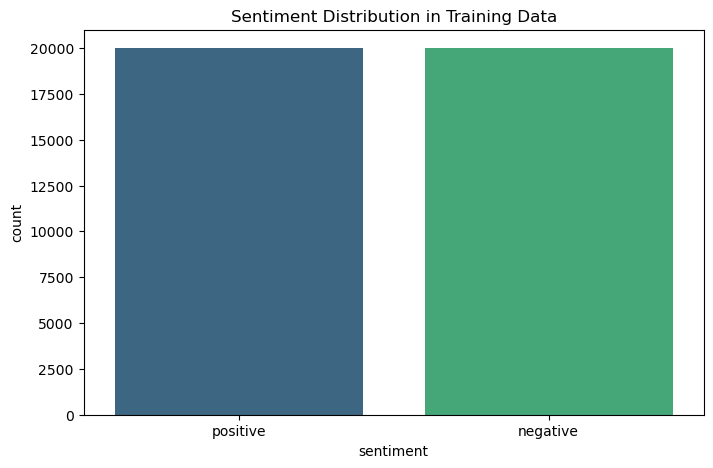

In [10]:
# Class distribution in the training data
print("Train sentiment distribution:\n", train_df['sentiment'].value_counts())

# Class distribution in the test data
print("Test sentiment distribution:\n", test_df['sentiment'].value_counts())

# Visualize the class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=train_df, palette='viridis')
plt.title('Sentiment Distribution in Training Data')
plt.show()

As we see the data is balanced, with equal amount of positive and negative sentinment instances

### **4. Text Length Analysis**
Analyzing the length of reviews (in terms of word count) can provide insights into whether positive and negative reviews differ in length.

In [13]:
# Create a new column for review length
train_df['review_length'] = train_df['review'].apply(lambda x: len(x.split()))
test_df['review_length'] = test_df['review'].apply(lambda x: len(x.split()))

# Check if the column is created
print(train_df[['review', 'review_length']].head())

                                              review  review_length
0  I caught this little gem totally by accident b...            161
1  I can't believe that I let myself into this mo...            170
2  *spoiler alert!* it just gets to me the nerve ...             69
3  If there's one thing I've learnt from watching...            314
4  I remember when this was in theaters, reviews ...            183


Highest review length: 2470 words
Lowest review length: 4 words
Median review length: 173.0 words


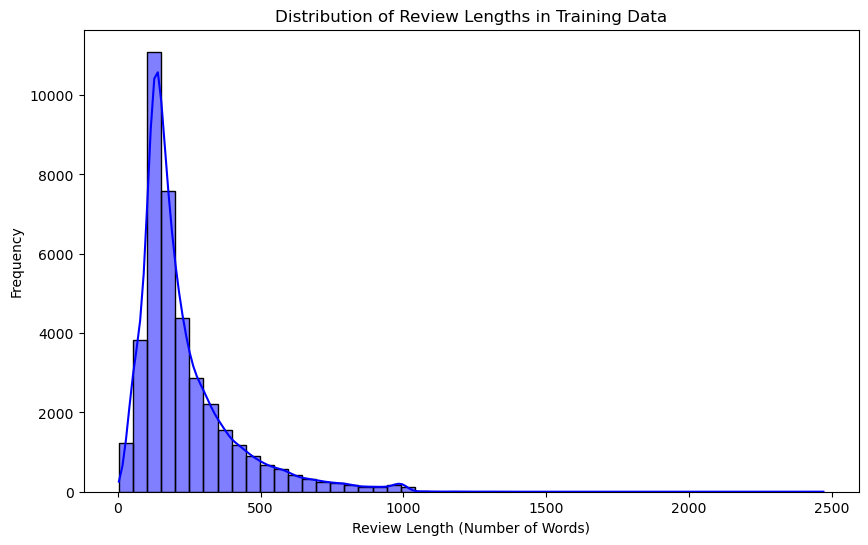

In [14]:
# Compute statistics
max_length = train_df['review_length'].max()
min_length = train_df['review_length'].min()
median_length = train_df['review_length'].median()

# Print statistics
print(f"Highest review length: {max_length} words")
print(f"Lowest review length: {min_length} words")
print(f"Median review length: {median_length} words")

# Visualize review length distribution
plt.figure(figsize=(10, 6))
sns.histplot(train_df['review_length'], bins=50, kde=True, color='blue')
plt.title('Distribution of Review Lengths in Training Data')
plt.xlabel('Review Length (Number of Words)')
plt.ylabel('Frequency')
plt.show()


### **5. Word Frequency Analysis**
Identifying the most common words in positive and negative reviews can help us understand the language patterns associated with each sentiment.

Most common words in positive reviews:
 [('the', 233464), ('and', 132560), ('a', 124453), ('of', 119303), ('to', 102793), ('is', 86482), ('in', 72259), ('that', 49884), ('I', 49869), ('it', 42762), ('this', 41311), ('/><br', 38810), ('as', 37175), ('with', 34591), ('was', 33691), ('for', 32902), ('The', 26200), ('but', 25751), ('his', 25279), ('on', 24470)]
Most common words in negative reviews:
 [('the', 222215), ('a', 121422), ('and', 109214), ('of', 107804), ('to', 107101), ('is', 75821), ('in', 63886), ('I', 56826), ('that', 51729), ('this', 49911), ('it', 43821), ('/><br', 41749), ('was', 40755), ('for', 32166), ('with', 31586), ('as', 29382), ('The', 27644), ('movie', 27573), ('but', 27186), ('on', 24512)]


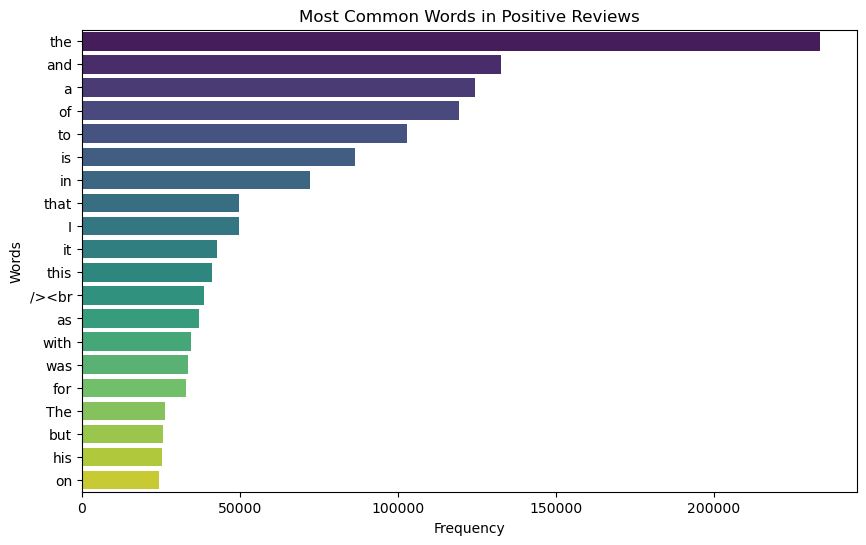

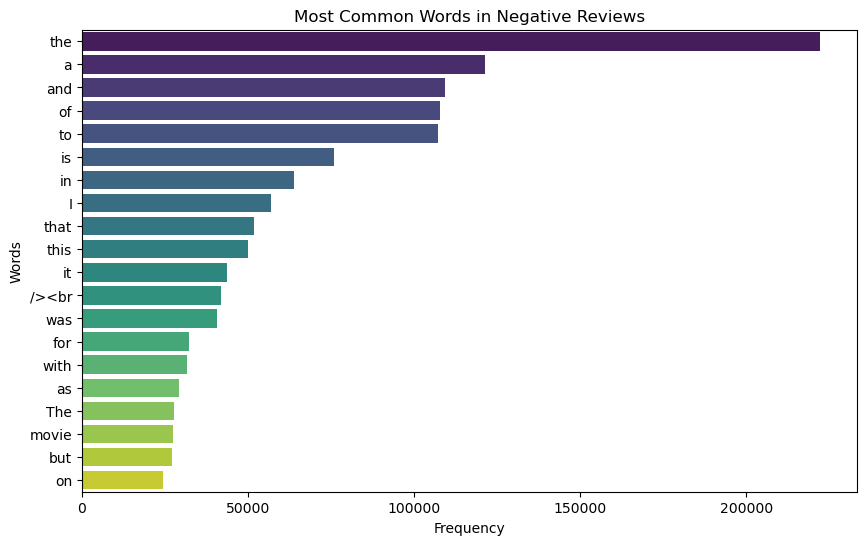

In [16]:
# Function to get the most common words
def get_most_common_words(texts, n=20):
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get most common words in positive and negative reviews
positive_reviews = train_df[train_df['sentiment'] == 'positive']['review']
negative_reviews = train_df[train_df['sentiment'] == 'negative']['review']

positive_common_words = get_most_common_words(positive_reviews)
negative_common_words = get_most_common_words(negative_reviews)

print("Most common words in positive reviews:\n", positive_common_words)
print("Most common words in negative reviews:\n", negative_common_words)

# Visualize the most common words
def plot_common_words(common_words, title):
    words, counts = zip(*common_words)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words), palette='viridis')
    plt.title(title)
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.show()

plot_common_words(positive_common_words, 'Most Common Words in Positive Reviews')
plot_common_words(negative_common_words, 'Most Common Words in Negative Reviews')

As we see the most common words are articles, pronounes, etc (stopwords). The reviewes also include HTML Tags. We should handle them in preprocessing and explore the data.

## Word cloud before processing

In [19]:
# Function to generate word clouds
def generate_wordcloud(texts, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(texts))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

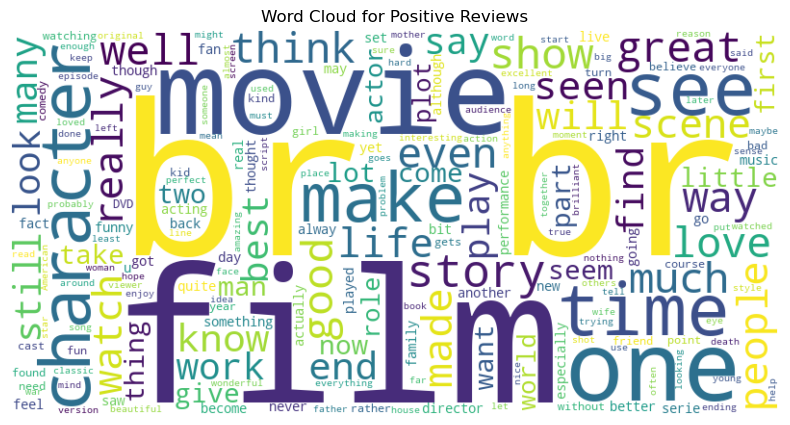

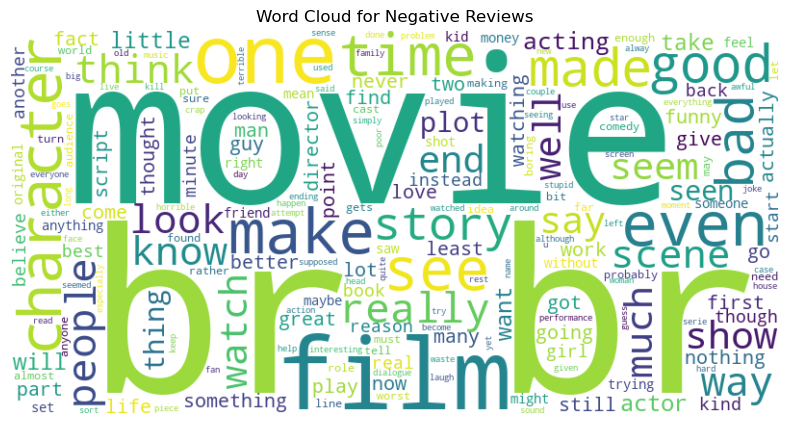

In [20]:
# Generate word clouds for positive and negative reviews
positive_reviews = train_df[train_df['sentiment'] == 'positive']['review']
negative_reviews = train_df[train_df['sentiment'] == 'negative']['review']

generate_wordcloud(positive_reviews, 'Word Cloud for Positive Reviews')
generate_wordcloud(negative_reviews, 'Word Cloud for Negative Reviews')

## N-gram Before Preprocessing

In [22]:
# Function to get top N-grams
def get_top_ngrams(texts, n=2, top_n=20):
    vec = CountVectorizer(ngram_range=(n, n)).fit(texts)
    bag_of_words = vec.transform(texts)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_n]

# Get top bigrams for positive and negative reviews
positive_bigrams = get_top_ngrams(positive_reviews, n=2)
negative_bigrams = get_top_ngrams(negative_reviews, n=2)

print("Top bigrams in positive reviews:\n", positive_bigrams)
print("Top bigrams in negative reviews:\n", negative_bigrams)

Top bigrams in positive reviews:
 [('br br', 38844), ('of the', 33407), ('in the', 20558), ('the film', 11788), ('and the', 11542), ('this movie', 10811), ('to the', 10277), ('it is', 9280), ('this film', 8758), ('the movie', 8247), ('this is', 8156), ('to be', 8038), ('one of', 7706), ('on the', 7215), ('with the', 6590), ('for the', 6443), ('it was', 6257), ('br the', 6077), ('at the', 5883), ('is the', 5794)]
Top bigrams in negative reviews:
 [('br br', 41793), ('of the', 28490), ('in the', 19744), ('this movie', 14441), ('the movie', 10720), ('to be', 10705), ('and the', 9885), ('the film', 9719), ('this film', 8757), ('to the', 8743), ('it was', 7412), ('on the', 7079), ('this is', 6840), ('it is', 6734), ('for the', 6435), ('br the', 6395), ('with the', 6004), ('if you', 5960), ('one of', 5307), ('is the', 5209)]


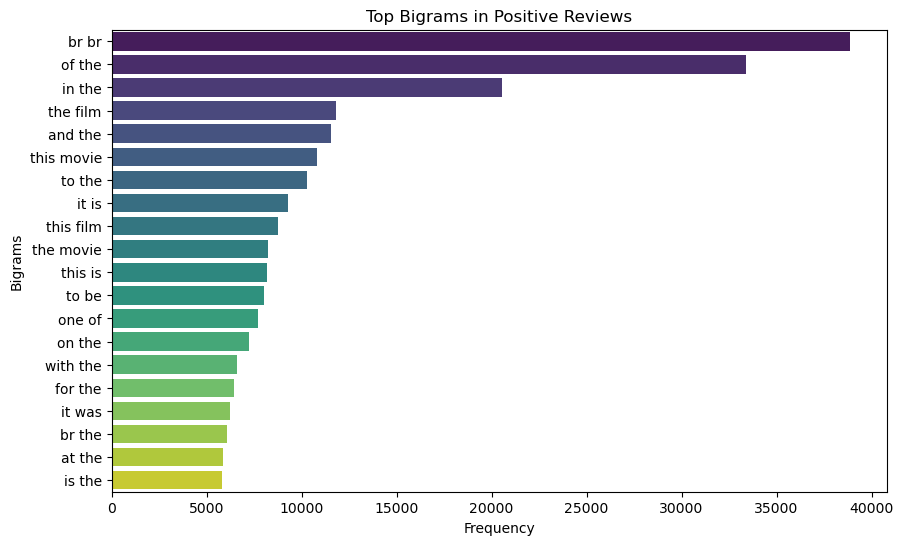

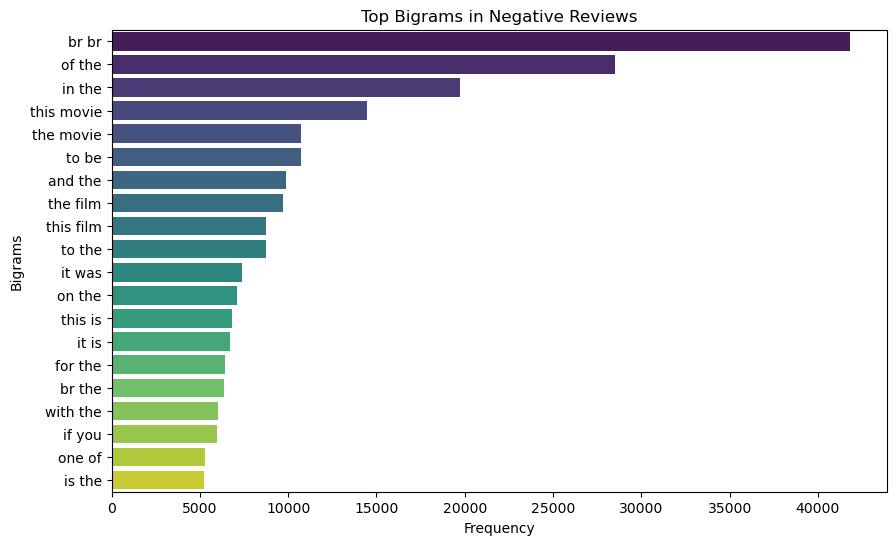

In [23]:
# Function to plot n-grams
def plot_ngrams(ngrams, title):
    words, counts = zip(*ngrams)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words), palette='viridis')
    plt.title(title)
    plt.xlabel('Frequency')
    plt.ylabel('Bigrams')
    plt.show()

# Plot bigrams
plot_ngrams(positive_bigrams, 'Top Bigrams in Positive Reviews')
plot_ngrams(negative_bigrams, 'Top Bigrams in Negative Reviews')

In [24]:
# Get top trigrams and 4-grams for positive and negative reviews
positive_trigrams = get_top_ngrams(positive_reviews, n=3)
negative_trigrams = get_top_ngrams(negative_reviews, n=3)

positive_4grams = get_top_ngrams(positive_reviews, n=4)
negative_4grams = get_top_ngrams(negative_reviews, n=4)

# Print results
print("Top trigrams in positive reviews:\n", positive_trigrams)
print("Top trigrams in negative reviews:\n", negative_trigrams)
print("Top 4-grams in positive reviews:\n", positive_4grams)
print("Top 4-grams in negative reviews:\n", negative_4grams)


Top trigrams in positive reviews:
 [('br br the', 6077), ('one of the', 4715), ('of the film', 2230), ('br br this', 1939), ('is one of', 1904), ('this movie is', 1816), ('the film is', 1685), ('some of the', 1660), ('this film is', 1451), ('of the movie', 1379), ('of the best', 1378), ('br br it', 1349), ('in the film', 1289), ('as well as', 1175), ('the movie is', 1100), ('in this film', 1099), ('of the most', 1063), ('the fact that', 1060), ('in this movie', 1053), ('in the movie', 1023)]
Top trigrams in negative reviews:
 [('br br the', 6395), ('one of the', 3190), ('this movie is', 2412), ('of the movie', 2047), ('of the film', 1891), ('br br this', 1746), ('in this movie', 1475), ('in the movie', 1401), ('some of the', 1392), ('this film is', 1335), ('this movie was', 1332), ('the movie is', 1321), ('br br it', 1281), ('the film is', 1248), ('the fact that', 1235), ('the rest of', 1214), ('in the film', 1191), ('in this film', 1099), ('most of the', 1066), ('supposed to be', 1018

## EDA Summary

From the EDA processes above we found out that the data suffers from extensive count of stopwords, html tags and url elemens appear in the text bodies. There is no Class disbalance in the data. Data has no significant outliers, and the ones that appear should be kept because they are reviews, and review can be any lenght. 

# Processing the Text 
Difficulty of the reviews written by humans with their subjective opinion makes it difficult to explore the data. We have to handle that in the first place, and then continue with the exploratory analysis.

* Removal of Duplicates
* Convert to Lowercase
* Removal of URLs and HTML Tags
* Expand Contractions
* Normalize Hyphens and Special Character
* Converting Emojis & emoticons to words
* Split Merged Words
* Remove punctuation and numbers 
* Remove Repeated sequences of words
* Expand Chat Words
* Tokenization
* Removing Stopwords
* Remove Short words
* Stemming VS Lemmatization
* Convert token back to text

## Removal of Duplicates

In [30]:
# Remove duplicate reviews
train_df = train_df.drop_duplicates(subset=['review']).reset_index(drop=True)
test_df = test_df.drop_duplicates(subset=['review']).reset_index(drop=True)
print("Duplicates removed successfully!")

Duplicates removed successfully!


In [31]:
# cleaned_review column copy of the original review column so that we can compare 
train_df['cleaned_review'] = train_df['review'].copy()
test_df['cleaned_review'] = test_df['review'].copy()

print("'cleaned_review' column initialized!")

'cleaned_review' column initialized!


## Convert To Lowercase 

In [33]:
train_df['cleaned_review'] = train_df['review'].str.lower()
test_df['cleaned_review'] = test_df['review'].str.lower()
print("Lowercasing done!")

Lowercasing done!


## Removal of URLs AND HTML Tags

In [35]:
def clean_html_urls(text):
    text = BeautifulSoup(text, "html.parser").get_text()  # Remove HTML
    text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)  # Remove URLs
    text = unicodedata.normalize("NFKD", text)  # Normalize unicode 
    return text

train_df['cleaned_review'] = train_df['cleaned_review'].apply(clean_html_urls)
test_df['cleaned_review'] = test_df['cleaned_review'].apply(clean_html_urls)
print("HTML tags and URLs removed successfully!")

HTML tags and URLs removed successfully!


## Expand Contractions

In [37]:
#Expand contractions
def expand_contractions(text):
    return contractions.fix(text)  

train_df['cleaned_review'] = train_df['cleaned_review'].apply(expand_contractions)
test_df['cleaned_review'] = test_df['cleaned_review'].apply(expand_contractions)
print("Contractions expanded successfully!")

Contractions expanded successfully!


## Normalize Hyphens and Special Character

In [39]:
def normalize_hyphens(text):
    text = text.replace("-", " ")  # Convert hyphens to spaces
    return text

train_df['cleaned_review'] = train_df['cleaned_review'].apply(normalize_hyphens)
test_df['cleaned_review'] = test_df['cleaned_review'].apply(normalize_hyphens)
print("Hyphens normalized successfully!")


Hyphens normalized successfully!


## Converting Emojis & emoticons to words

In [41]:
# Function to replace emoticons with meaningful words
def convert_emojis(text):
    return emoji.demojize(text, delimiters=(" ", " "))

# Apply updated functions to datasets
train_df['cleaned_review'] = train_df['cleaned_review'].apply(convert_emojis)
test_df['cleaned_review'] = test_df['cleaned_review'].apply(convert_emojis)

print("Emojis converted to text successfully!")

Emojis converted to text successfully!


## Split Merged Words

In [43]:
def split_merged_words(text):
    words = text.split()
    words = [" ".join(wordninja.split(word)) if len(word) > 8 else word for word in words]  
    return " ".join(words)

train_df['cleaned_review'] = train_df['cleaned_review'].apply(split_merged_words)
test_df['cleaned_review'] = test_df['cleaned_review'].apply(split_merged_words)
print("Merged words split successfully!")

Merged words split successfully!


## Remove punctuation and numbers

In [45]:
def remove_punctuation_numbers(text):
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = re.sub(r'\d+', '', text)  # Remove numbers
    return text

train_df['cleaned_review'] = train_df['cleaned_review'].apply(remove_punctuation_numbers)
test_df['cleaned_review'] = test_df['cleaned_review'].apply(remove_punctuation_numbers)
print("Numbers and punctuation removed successfully!")

Numbers and punctuation removed successfully!


## Remove Repeated sequences of words

In [47]:
def remove_repeated_phrases(text):
    """Remove sequences of repeated words and phrases in text efficiently."""
    pattern = re.compile(r"\b(\w+(?:\s+\w+){0,5})\b(?:\s+\1\b)+", re.IGNORECASE)
    return pattern.sub(r"\1", text)  

# Apply to DataFrame
train_df['cleaned_review'] = train_df['cleaned_review'].apply(remove_repeated_phrases)
test_df['cleaned_review'] = test_df['cleaned_review'].apply(remove_repeated_phrases)

print("Repeated phrases removed successfully!")

Repeated phrases removed successfully!


## Tokenization

In [49]:
nltk.download('punkt')
nltk.download('punkt_tab')

# since cleaned_review overwrite text multiple times, we make copy of original
train_df['cleaned_review_pre_token'] = train_df['cleaned_review']
test_df['cleaned_review_pre_token'] = test_df['cleaned_review']

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [50]:
train_df['tokens'] = train_df['cleaned_review'].apply(word_tokenize)
test_df['tokens'] = test_df['cleaned_review'].apply(word_tokenize)
print("Tokenization completed successfully!")

Tokenization completed successfully!


## Removing Stopwords

In [52]:
# Remove Stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

train_df['tokens'] = train_df['tokens'].apply(remove_stopwords)
test_df['tokens'] = test_df['tokens'].apply(remove_stopwords)

print("Stopwords removed successfully!")
print(train_df['tokens'].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Stopwords removed successfully!
0    [caught, little, gem, totally, accident, back,...
1    [believe, let, movie, accomplish, favor, frien...
2    [spoiler, alert, gets, nerve, people, remake, ...
3    [one, thing, learnt, watching, george, romeros...
4    [remember, theaters, reviews, said, horrible, ...
Name: tokens, dtype: object


## Remove Short words

In [54]:
def remove_short_words(tokens):
    return [word for word in tokens if len(word) > 2]

train_df['tokens'] = train_df['tokens'].apply(remove_short_words)
test_df['tokens'] = test_df['tokens'].apply(remove_short_words)
print("Short words removed successfully!")

Short words removed successfully!


## Convert tokens back to string for Word2Vec processin

In [56]:
# Convert tokens back to string for Word2Vec processing
def tokens_to_string(tokens):
    return " ".join(tokens)

# Ensure Word2Vec-ready data is created in memory
train_df['word2vec_review'] = train_df['tokens'].apply(tokens_to_string)
test_df['word2vec_review'] = test_df['tokens'].apply(tokens_to_string)

print("Word2Vec-ready text is prepared in memory!")

Word2Vec-ready text is prepared in memory!


## Stemming VS Lemmatization

In [58]:

nltk.download('wordnet')

# Initialize Stemmer and Lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Function to apply stemming
def apply_stemming(tokens):
    return [stemmer.stem(word) for word in tokens]  # Apply on tokens directly

# Function to apply lemmatization
def apply_lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]  # Apply on tokens directly

# Apply stemming to tokenized text
train_df['stemmed_tokens'] = train_df['tokens'].apply(apply_stemming)
test_df['stemmed_tokens'] = test_df['tokens'].apply(apply_stemming)

# Apply lemmatization to tokenized text
train_df['lemmatized_tokens'] = train_df['tokens'].apply(apply_lemmatization)
test_df['lemmatized_tokens'] = test_df['tokens'].apply(apply_lemmatization)

print("Stemming and Lemmatization applied successfully!")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Stemming and Lemmatization applied successfully!


## Convert token back to text

In [60]:
# Convert tokens back to string for both stemming and lemmatization
def tokens_to_string(tokens):
    return " ".join(tokens)

train_df['stemmed_review'] = train_df['stemmed_tokens'].apply(tokens_to_string)
test_df['stemmed_review'] = test_df['stemmed_tokens'].apply(tokens_to_string)

train_df['lemmatized_review'] = train_df['lemmatized_tokens'].apply(tokens_to_string)
test_df['lemmatized_review'] = test_df['lemmatized_tokens'].apply(tokens_to_string)

print("Tokenized words converted back to string successfully for both stemming and lemmatization!")

# Display a few sample results to verify
print(train_df[['review', 'cleaned_review', 'stemmed_review', 'lemmatized_review']].head())

Tokenized words converted back to string successfully for both stemming and lemmatization!
                                              review  \
0  I caught this little gem totally by accident b...   
1  I can't believe that I let myself into this mo...   
2  *spoiler alert!* it just gets to me the nerve ...   
3  If there's one thing I've learnt from watching...   
4  I remember when this was in theaters, reviews ...   

                                      cleaned_review  \
0  i caught this little gem totally by accident b...   
1  i cannot believe that i let myself into this m...   
2  spoiler alert it just gets to me the nerve som...   
3  if there is one thing i have learnt from watch...   
4  i remember when this was in theaters reviews s...   

                                      stemmed_review  \
0  caught littl gem total accid back reviv theatr...   
1  believ let movi accomplish favor friend ask ea...   
2  spoiler alert get nerv peopl remak use term lo...   
3  one thin

What are the steps that were skipped on this particular case:

* Named Entity Recognition

This technique was explored, and was skipped due to its extensive computational costs relative to the benefit it gave. This preprocessing method did not give substantial benefit to include it in the general preprocessing.

* Spell Checker

Even simple spell checkers were computationally slow and had no substantial impact on the performance of the model, so they were skipped.

* Frequent & Rare words.

From the specifics of the data, I did not take it reasonable to omit these words.

* Expand Chat words

After testing several times, I did not find this method very beneficial


# EDA on preprocessed Data

In [63]:
train_df['cleaned_review'].head()

0    i caught this little gem totally by accident b...
1    i cannot believe that i let myself into this m...
2    spoiler alert it just gets to me the nerve som...
3    if there is one thing i have learnt from watch...
4    i remember when this was in theaters reviews s...
Name: cleaned_review, dtype: object

## Correlation Analysis

In [65]:
# Function to get sentiment polarity
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Apply sentiment analysis separately for stemmed and lemmatized versions
train_df['sentiment_polarity_stem'] = train_df['stemmed_review'].apply(get_sentiment)
train_df['sentiment_polarity_lem'] = train_df['lemmatized_review'].apply(get_sentiment)

print("Sentiment polarity calculated successfully for both stemming and lemmatization!")

Sentiment polarity calculated successfully for both stemming and lemmatization!


For EDA purposes we used simple TextBlob to have naive polarity of sentiment and depict correlation with review_lenght

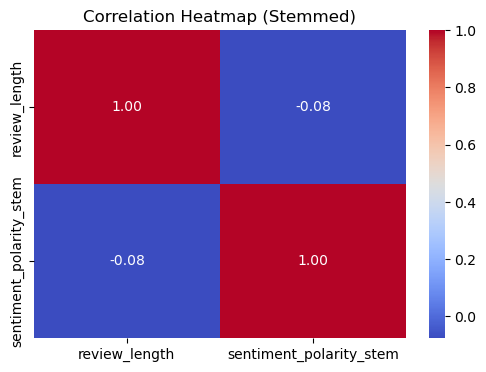

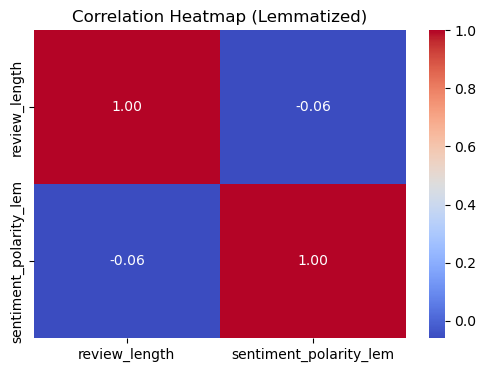

In [67]:
# Compute correlation matrix separately
correlation_matrix_stem = train_df[['review_length', 'sentiment_polarity_stem']].corr()
correlation_matrix_lem = train_df[['review_length', 'sentiment_polarity_lem']].corr()

# Heatmap visualization for stemmed
plt.figure(figsize=(6,4))
sns.heatmap(correlation_matrix_stem, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Stemmed)")
plt.show()

# Heatmap visualization for lemmatized
plt.figure(figsize=(6,4))
sns.heatmap(correlation_matrix_lem, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Lemmatized)")
plt.show()

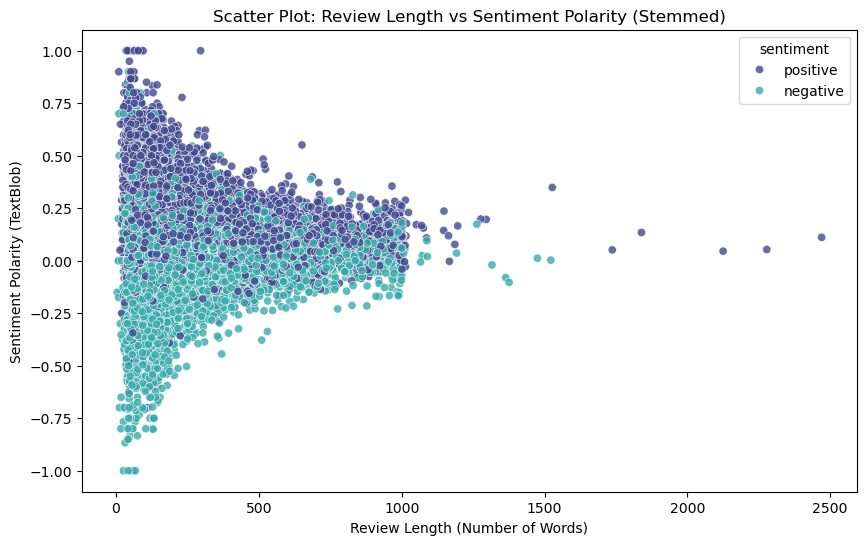

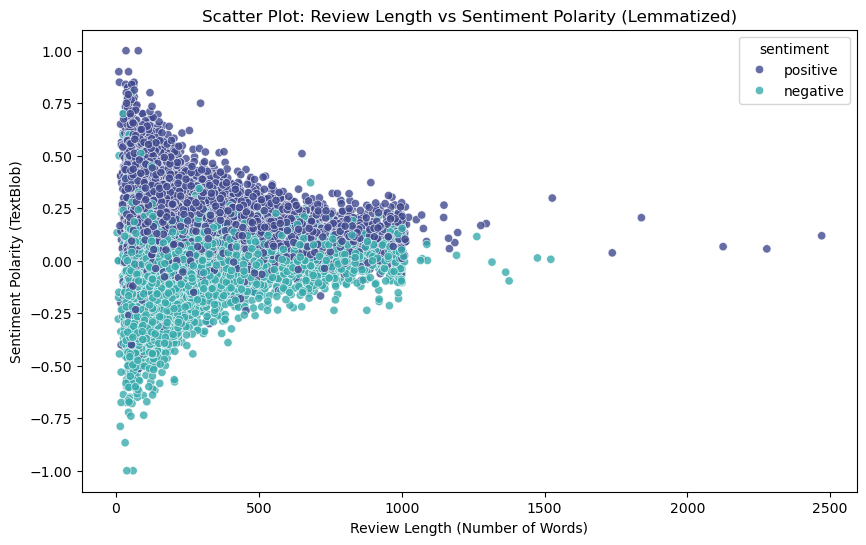

In [68]:
# Scatter plot for stemmed reviews
plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df['review_length'], y=train_df['sentiment_polarity_stem'], hue=train_df['sentiment'], alpha=0.8, palette='mako')
plt.title("Scatter Plot: Review Length vs Sentiment Polarity (Stemmed)")
plt.xlabel("Review Length (Number of Words)")
plt.ylabel("Sentiment Polarity (TextBlob)")
plt.show()

# Scatter plot for lemmatized reviews
plt.figure(figsize=(10, 6))
sns.scatterplot(x=train_df['review_length'], y=train_df['sentiment_polarity_lem'], hue=train_df['sentiment'], alpha=0.8, palette='mako')
plt.title("Scatter Plot: Review Length vs Sentiment Polarity (Lemmatized)")
plt.xlabel("Review Length (Number of Words)")
plt.ylabel("Sentiment Polarity (TextBlob)")
plt.show()

According to coefficients above the correlation between lenght and sentiment polarity is very weak, meaning longer reviews do not strongly impact polarity of sentiment. Review lenght is not reliable predictor of sentiment.

Scatter plot is showing wide range of spread. For reviews with less than 500 words sentiment varies widely, from -1 to +1 (very roughly speaking), and longer reviews with more than 1000 tend to be more neutral. negative reviews are more concentrated in low review lenghts instances, but this is not giving us any foundation to base our predictions. 

## Word Cloud Visualization

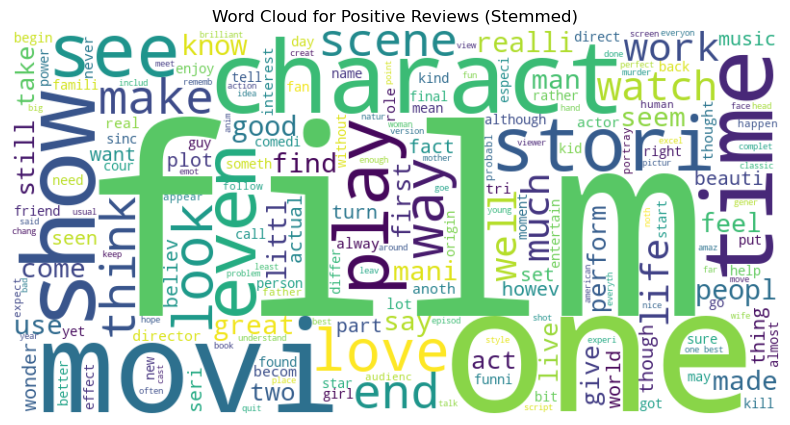

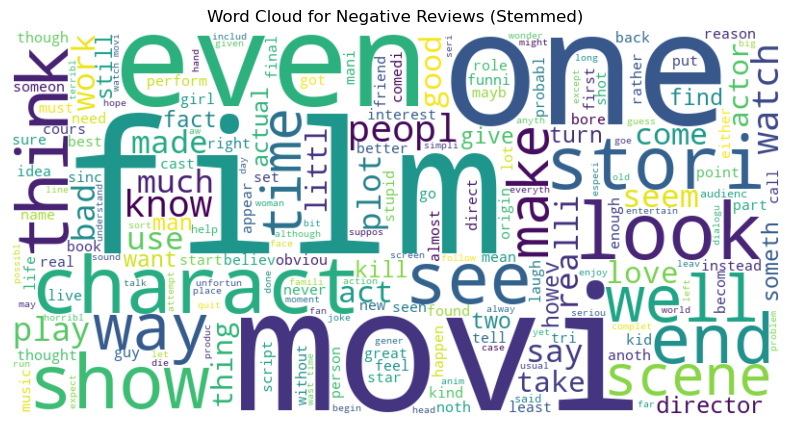

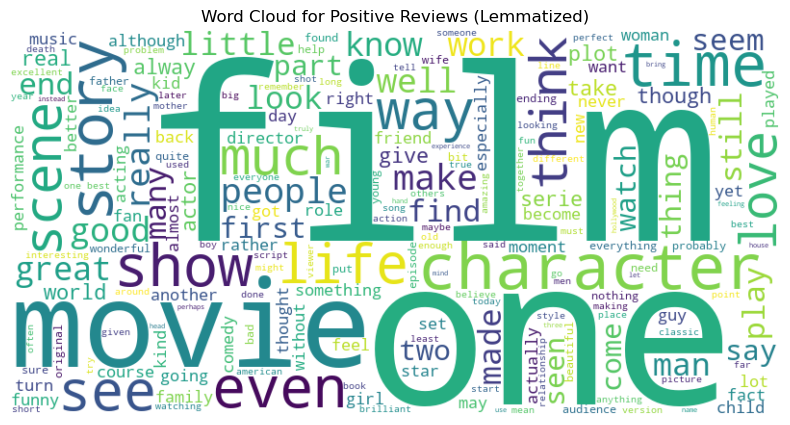

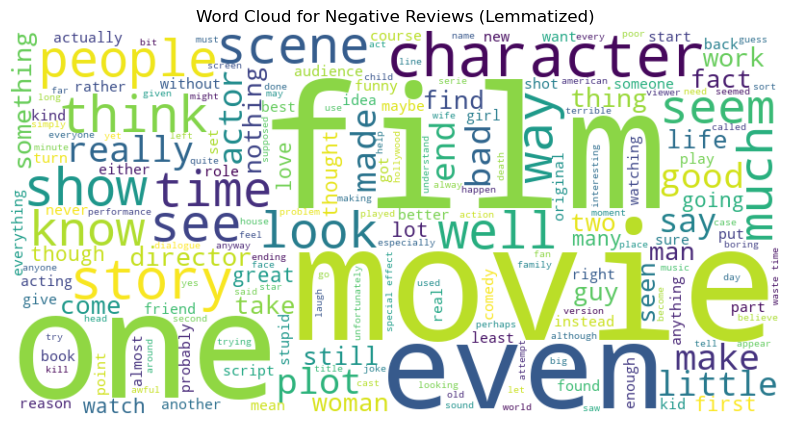

In [71]:
# Generate word clouds for positive and negative reviews (stemmed & lemmatized)
positive_reviews_stem = train_df[train_df['sentiment'] == 'positive']['stemmed_review']
negative_reviews_stem = train_df[train_df['sentiment'] == 'negative']['stemmed_review']

positive_reviews_lem = train_df[train_df['sentiment'] == 'positive']['lemmatized_review']
negative_reviews_lem = train_df[train_df['sentiment'] == 'negative']['lemmatized_review']

# Word clouds for stemmed
generate_wordcloud(positive_reviews_stem, 'Word Cloud for Positive Reviews (Stemmed)')
generate_wordcloud(negative_reviews_stem, 'Word Cloud for Negative Reviews (Stemmed)')

# Word clouds for lemmatized
generate_wordcloud(positive_reviews_lem, 'Word Cloud for Positive Reviews (Lemmatized)')
generate_wordcloud(negative_reviews_lem, 'Word Cloud for Negative Reviews (Lemmatized)')


In contrast with inital Word Cloud visualization, we can see that now other, more reasonable words are present in the clouds, meaning, we got rid of stopwords and unnecessary tags. 

## N-gram Analysis

In [74]:
# Get top bigrams for positive and negative reviews (stemmed)
positive_bigrams_stem = get_top_ngrams(positive_reviews_stem, n=2)
negative_bigrams_stem = get_top_ngrams(negative_reviews_stem, n=2)

print("Top bigrams in positive reviews (Stemmed):\n", positive_bigrams_stem)
print("Top bigrams in negative reviews (Stemmed):\n", negative_bigrams_stem)

# Get top bigrams for positive and negative reviews (lemmatized)
positive_bigrams_lem = get_top_ngrams(positive_reviews_lem, n=2)
negative_bigrams_lem = get_top_ngrams(negative_reviews_lem, n=2)

print("Top bigrams in positive reviews (Lemmatized):\n", positive_bigrams_lem)
print("Top bigrams in negative reviews (Lemmatized):\n", negative_bigrams_lem)

Top bigrams in positive reviews (Stemmed):
 [('one best', 1338), ('watch movi', 1024), ('even though', 855), ('year old', 840), ('ever seen', 767), ('see movi', 764), ('first time', 755), ('look like', 752), ('highli recommend', 713), ('main charact', 679), ('new york', 674), ('movi like', 660), ('special effect', 653), ('good movi', 639), ('watch film', 635), ('must see', 629), ('great movi', 617), ('year ago', 613), ('see film', 598), ('real life', 586)]
Top bigrams in negative reviews (Stemmed):
 [('look like', 2249), ('watch movi', 1414), ('ever seen', 1326), ('wast time', 1303), ('special effect', 1199), ('movi ever', 1059), ('year old', 1018), ('bad movi', 1018), ('low budget', 999), ('worst movi', 913), ('movi like', 874), ('main charact', 874), ('horror movi', 870), ('make movi', 842), ('much better', 805), ('seem like', 793), ('see movi', 775), ('want see', 772), ('one worst', 752), ('even though', 719)]
Top bigrams in positive reviews (Lemmatized):
 [('one best', 1338), ('eve

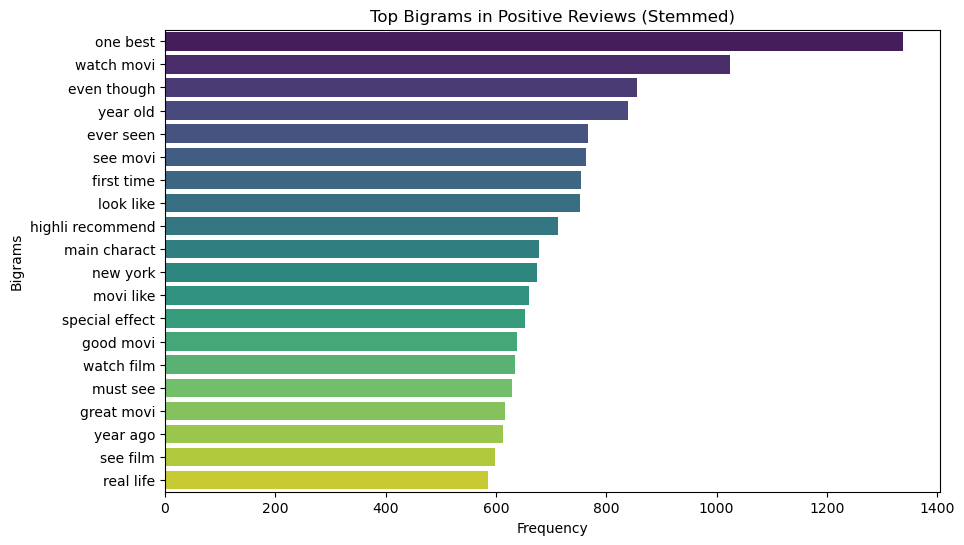

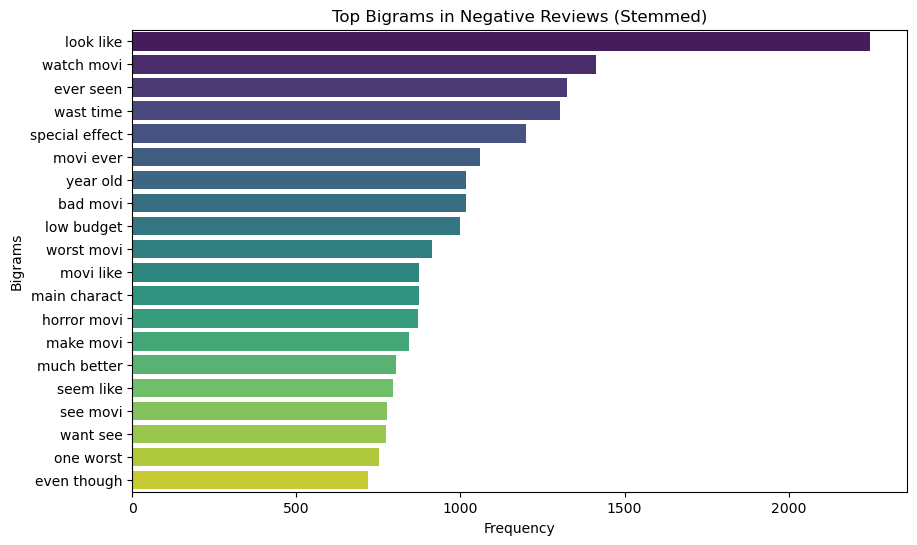

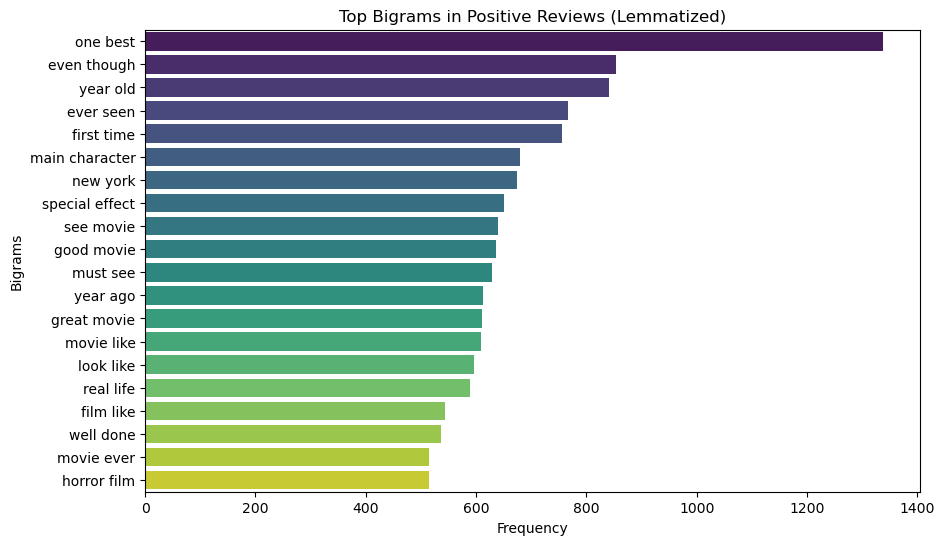

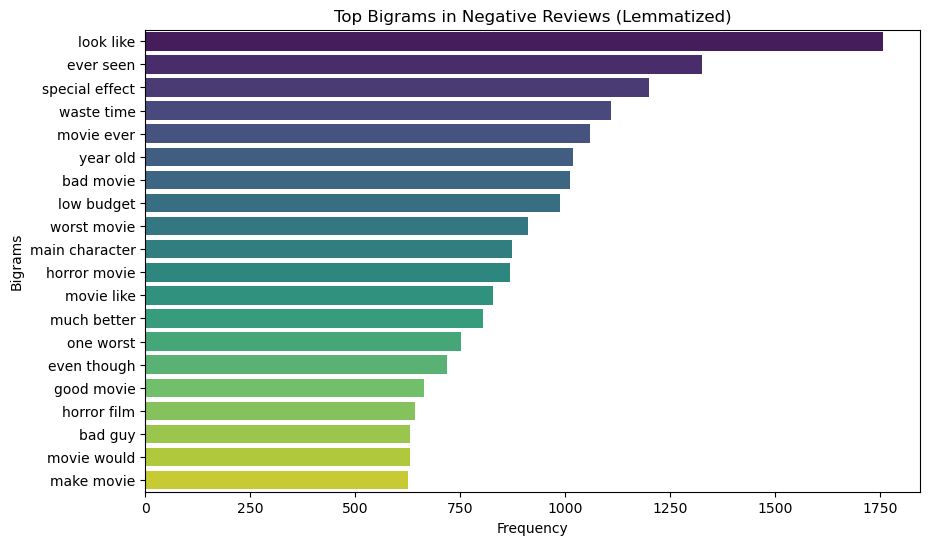

In [75]:
# Plot bigrams
plot_ngrams(positive_bigrams_stem, 'Top Bigrams in Positive Reviews (Stemmed)')
plot_ngrams(negative_bigrams_stem, 'Top Bigrams in Negative Reviews (Stemmed)')

plot_ngrams(positive_bigrams_lem, 'Top Bigrams in Positive Reviews (Lemmatized)')
plot_ngrams(negative_bigrams_lem, 'Top Bigrams in Negative Reviews (Lemmatized)')

In [76]:
# Get top trigrams and 4-grams (Stemmed)
positive_trigrams_stem = get_top_ngrams(positive_reviews_stem, n=3)
negative_trigrams_stem = get_top_ngrams(negative_reviews_stem, n=3)

positive_4grams_stem = get_top_ngrams(positive_reviews_stem, n=4)
negative_4grams_stem = get_top_ngrams(negative_reviews_stem, n=4)

# Get top trigrams and 4-grams (Lemmatized)
positive_trigrams_lem = get_top_ngrams(positive_reviews_lem, n=3)
negative_trigrams_lem = get_top_ngrams(negative_reviews_lem, n=3)

positive_4grams_lem = get_top_ngrams(positive_reviews_lem, n=4)
negative_4grams_lem = get_top_ngrams(negative_reviews_lem, n=4)

# Print results
print("Top trigrams in positive reviews (Stemmed):\n", positive_trigrams_stem)
print("Top trigrams in negative reviews (Stemmed):\n", negative_trigrams_stem)
print("Top 4-grams in positive reviews (Stemmed):\n", positive_4grams_stem)
print("Top 4-grams in negative reviews (Stemmed):\n", negative_4grams_stem)

print("Top trigrams in positive reviews (Lemmatized):\n", positive_trigrams_lem)
print("Top trigrams in negative reviews (Lemmatized):\n", negative_trigrams_lem)
print("Top 4-grams in positive reviews (Lemmatized):\n", positive_4grams_lem)
print("Top 4-grams in negative reviews (Lemmatized):\n", negative_4grams_lem)

Top trigrams in positive reviews (Stemmed):
 [('movi ever seen', 188), ('new york citi', 151), ('ca save te', 148), ('one best movi', 131), ('film ever made', 126), ('one best film', 124), ('base true stori', 110), ('best movi ever', 106), ('film ever seen', 99), ('movi ever made', 95), ('would like see', 95), ('would love see', 94), ('well worth watch', 90), ('first time saw', 87), ('seen long time', 78), ('first saw movi', 74), ('intern film festiv', 71), ('highli recommend movi', 66), ('one time favorit', 65), ('mani year ago', 63)]
Top trigrams in negative reviews (Stemmed):
 [('worst movi ever', 598), ('movi ever seen', 491), ('worst film ever', 276), ('one worst movi', 258), ('film ever seen', 243), ('movi ever made', 202), ('wast time money', 169), ('one worst film', 144), ('film ever made', 127), ('low budget movi', 103), ('bad act bad', 101), ('complet wast time', 99), ('wast time watch', 96), ('low budget film', 92), ('movi look like', 91), ('worst movi seen', 84), ('make loo

Compared to N-grams that we had before the processing, this is way cleaner and better combination of words that will help us in the building of model

## Side by Side Visualization before and after processing

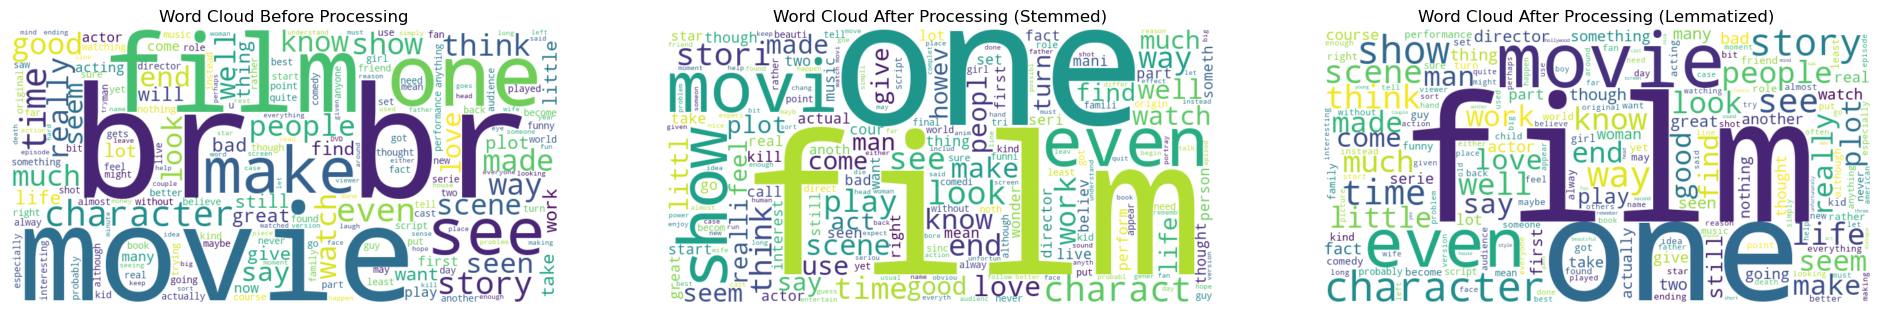

In [79]:
# Word Cloud Before and After Processing (3-way comparison)
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# Before Processing
wordcloud_raw = WordCloud(width=800, height=400, background_color='white').generate(" ".join(train_df['review']))
axes[0].imshow(wordcloud_raw, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title("Word Cloud Before Processing")

# After Processing (Stemmed)
wordcloud_stem = WordCloud(width=800, height=400, background_color='white').generate(" ".join(train_df['stemmed_review']))
axes[1].imshow(wordcloud_stem, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title("Word Cloud After Processing (Stemmed)")

# After Processing (Lemmatized)
wordcloud_lem = WordCloud(width=800, height=400, background_color='white').generate(" ".join(train_df['lemmatized_review']))
axes[2].imshow(wordcloud_lem, interpolation='bilinear')
axes[2].axis('off')
axes[2].set_title("Word Cloud After Processing (Lemmatized)")

plt.show()

## What has been done so far:

* Duplicate removal 
* Lowercasing 
* HTML tag & URL removal 
* Emoji & emoticon conversion 
* Punctuation & number removal 
* Chat word expansion 
* Stopword removal 
* Short word removal 
* Tokenization & re-conversion 

In [82]:
# Create separate DataFrames for lemmatized and stemmed versions
train_df_lem = train_df[['review', 'lemmatized_review', 'sentiment']].copy()
test_df_lem = test_df[['review', 'lemmatized_review', 'sentiment']].copy()

train_df_stem = train_df[['review', 'stemmed_review', 'sentiment']].copy()
test_df_stem = test_df[['review', 'stemmed_review', 'sentiment']].copy()

# Rename columns for clarity
train_df_lem.rename(columns={'lemmatized_review': 'cleaned_review'}, inplace=True)
test_df_lem.rename(columns={'lemmatized_review': 'cleaned_review'}, inplace=True)

train_df_stem.rename(columns={'stemmed_review': 'cleaned_review'}, inplace=True)
test_df_stem.rename(columns={'stemmed_review': 'cleaned_review'}, inplace=True)

print(" Separate DataFrames created for Lemmatized and Stemmed versions!")


🔹 Separate DataFrames created for Lemmatized and Stemmed versions!


## Display processed values and Compare

In [84]:
print("Lemmatized Reviews:\n")
print(train_df_lem[['review', 'cleaned_review']].head(10).to_string())

print("\nStemmed Reviews:\n")
print(train_df_stem[['review', 'cleaned_review']].head(10).to_string())

Lemmatized Reviews:

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

Steeming aggresively reduces words to their base form, and in most cases the reduced word loses its meaning. For example, the same sentence was handled in the follwoing way:

#### Word Reduction
* Lemmatized: believe let movie accomplish favor
* Stemmed: believ let movi accomplish favor

Taken from record #1

here, the word 'movie' was reduced to 'movi', 'believe' to 'beliv' which is losing readability of the text body. 

Apart from that, lemmatization considers the context of the word and returns a meaningful word, which is captured in the example:

#### Context awareness
* Lemmatized: cocaine craving
* Stemmed: cocain crave

Taken from record #7

Here, "cocaine" is preserved in the lemmatized version, but the stemmed version reduces it to "cocain," which is not an actual word.

#### Grammar and Readbility
* Lemmatized: director trying put nervous fast paced edgy
* Stemmed: director tri put nervou fast pace edgi

Taken from record #7

As we can see, the lemmatization maintains better sentence structure compared to stemming

#### Plural Forms 

* Lemmatized: movies
* Stemmed: movi

Taken from record #0

Lemmatized text bodes keep correct plural forms of the words

#### Loss of Meaning

Steamming sometimes reduced the word so that it becomes completely unrecognizable

* Lemmatized: flamboyance combined fear exposure
* Stemmed: flamboy combin fear exposur

Taken from record #8

"Flamboyance" is preserved in lemmatization but turns into "flamboy" in stemming, which loses meaning.

#### Summary
Lemmatization is more accurate, it keeps words intact and readable, and worsk well. Stemming is faster and lighter to apply, but since our data is not execessively large, it does not bring forth too high computational costs, so since our goal is sentiment analysis, lemmatization is prefarable. Had we had our focus on lighweight preprocessing, stemming woudl have been fine but this is not the case. We have both DataFrames, and we can compare performance of the same models for the Stemmed data and lemmatized Data.

# Vectorization 

We have cleaned and preprocessed data that has preserved meaningful word relationships, so accordingly we should first test out the vectorization technique that goes well with this type of data.

In [88]:
# Directly use DataFrames from EDA step
train_lemmatized, test_lemmatized = train_df_lem, test_df_lem
train_stemmed, test_stemmed = train_df_stem, test_df_stem
train_tokenized, test_tokenized = train_df, test_df

In [89]:
X_train_lem, X_test_lem = train_df_lem["cleaned_review"], test_df_lem["cleaned_review"]
y_train_lem, y_test_lem = train_df_lem["sentiment"], test_df_lem["sentiment"]

X_train_stem, X_test_stem = train_df_stem["cleaned_review"], test_df_stem["cleaned_review"]
y_train_stem, y_test_stem = train_df_stem["sentiment"], test_df_stem["sentiment"]

X_train_tokenized, X_test_tokenized = train_df["word2vec_review"], test_df["word2vec_review"]
y_train_tokenized, y_test_tokenized = train_df["sentiment"], test_df["sentiment"]

## TF-IDF

TF-IDF works well with traditional models like LR, SVM, etc. it is lightweight and works well with lemmatized words and tokenized text. The downside is that it ignores word context. While the reviews are mostly contextual, there most likely is word or set of words that would be good in classification. 

In [92]:
# Initialize TF-IDF vectorizers separately
tfidf_vectorizer_lem = TfidfVectorizer(ngram_range=(1,4), max_features=50000)
tfidf_vectorizer_stem = TfidfVectorizer(ngram_range=(1,4), max_features=50000)

# Fit & Transform TF-IDF for Lemmatized Data
X_train_tfidf_lem = tfidf_vectorizer_lem.fit_transform(X_train_lem)
X_test_tfidf_lem = tfidf_vectorizer_lem.transform(X_test_lem)

# Fit & Transform TF-IDF for Stemmed Data
X_train_tfidf_stem = tfidf_vectorizer_stem.fit_transform(X_train_stem)
X_test_tfidf_stem = tfidf_vectorizer_stem.transform(X_test_stem)

# Check shapes
print("TF-IDF Lemmatized Train Shape:", X_train_tfidf_lem.shape)
print("TF-IDF Stemmed Train Shape:", X_train_tfidf_stem.shape)

TF-IDF Lemmatized Train Shape: (39728, 50000)
TF-IDF Stemmed Train Shape: (39728, 50000)


### Lemmatized Data

In [94]:
# Get feature names
feature_names_lem = tfidf_vectorizer_lem.get_feature_names_out()

# Sum TF-IDF scores across all documents
tfidf_scores_lem = np.asarray(X_train_tfidf_lem.sum(axis=0)).flatten()

# Get top n-grams by TF-IDF score
top_n_idx_lem = np.argsort(tfidf_scores_lem)[::-1][:20]
top_ngrams_lem = [feature_names_lem[i] for i in top_n_idx_lem]
top_scores_lem = [tfidf_scores_lem[i] for i in top_n_idx_lem]

print("\nTop 20 N-grams by TF-IDF Score (Lemmatized):")
for ngram, score in zip(top_ngrams_lem, top_scores_lem):
    print(f"{ngram}: {score:.2f}")

# Inspect a sample document
sample_vector_lem = X_train_tfidf_lem[0].toarray().flatten()
nonzero_indices_lem = np.where(sample_vector_lem > 0)[0]
sample_features_lem = [feature_names_lem[i] for i in nonzero_indices_lem]
sample_scores_lem = [sample_vector_lem[i] for i in nonzero_indices_lem]

print("\nTF-IDF Representation of Sample Document (Lemmatized):")
for feat, score in zip(sample_features_lem[:20], sample_scores_lem[:20]):  
    print(f"{feat}: {score:.4f}")



Top 20 N-grams by TF-IDF Score (Lemmatized):
movie: 1688.16
film: 1457.60
one: 876.39
like: 741.70
good: 640.28
would: 633.74
time: 621.02
character: 602.77
story: 574.81
see: 540.44
really: 537.03
even: 528.71
get: 524.15
make: 515.51
bad: 496.76
scene: 492.62
great: 481.69
show: 480.58
well: 480.26
people: 453.79

TF-IDF Representation of Sample Document (Lemmatized):
accident: 0.0889
also: 0.0391
also know: 0.1251
amusing: 0.0826
audience: 0.1156
back: 0.0475
biggest: 0.0822
bun: 0.1347
bunch: 0.0752
came: 0.1257
camera: 0.0621
camera give: 0.1442
caught: 0.0807
chew: 0.1158
could: 0.0383
could stop: 0.1170
could stop laughing: 0.1327
definite: 0.1049
deliberately: 0.1090
dialogue: 0.1283


### Stemmed Data

In [96]:
# Get feature names
feature_names_stem = tfidf_vectorizer_stem.get_feature_names_out()

# Sum TF-IDF scores across all documents
tfidf_scores_stem = np.asarray(X_train_tfidf_stem.sum(axis=0)).flatten()

# Get top n-grams by TF-IDF score
top_n_idx_stem = np.argsort(tfidf_scores_stem)[::-1][:20]
top_ngrams_stem = [feature_names_stem[i] for i in top_n_idx_stem]
top_scores_stem = [tfidf_scores_stem[i] for i in top_n_idx_stem]

print("\nTop 20 N-grams by TF-IDF Score (Stemmed):")
for ngram, score in zip(top_ngrams_stem, top_scores_stem):
    print(f"{ngram}: {score:.2f}")

# Inspect a sample document
sample_vector_stem = X_train_tfidf_stem[0].toarray().flatten()
nonzero_indices_stem = np.where(sample_vector_stem > 0)[0]
sample_features_stem = [feature_names_stem[i] for i in nonzero_indices_stem]
sample_scores_stem = [sample_vector_stem[i] for i in nonzero_indices_stem]

print("\nTF-IDF Representation of Sample Document (Stemmed):")
for feat, score in zip(sample_features_stem[:20], sample_scores_stem[:20]):  
    print(f"{feat}: {score:.4f}")



Top 20 N-grams by TF-IDF Score (Stemmed):
movi: 1675.74
film: 1468.05
one: 870.61
like: 786.61
watch: 650.63
good: 640.11
would: 629.31
time: 622.41
charact: 598.20
see: 597.13
make: 588.18
stori: 571.02
get: 564.93
realli: 533.00
even: 531.36
show: 513.70
bad: 494.79
scene: 489.04
well: 481.95
great: 481.16

TF-IDF Representation of Sample Document (Stemmed):
accid: 0.0923
also: 0.0407
also know: 0.1299
amus: 0.0811
audienc: 0.1203
back: 0.0492
biggest: 0.0855
bun: 0.1402
bunch: 0.0782
came: 0.1308
camera: 0.0646
camera give: 0.1501
caught: 0.0840
chew: 0.1101
could: 0.0398
could stop: 0.1195
could stop laugh: 0.1382
definit: 0.0640
deliber: 0.1049
dialogu: 0.1335


## CountVectorizer

In [98]:
# Initialize separate CountVectorizers
count_vectorizer_lem = CountVectorizer(ngram_range=(1,4), max_features=50000)
count_vectorizer_stem = CountVectorizer(ngram_range=(1,4), max_features=50000)

# Fit & Transform CountVectorizer for Lemmatized Data
X_train_count_lem = count_vectorizer_lem.fit_transform(X_train_lem)
X_test_count_lem = count_vectorizer_lem.transform(X_test_lem)

# Fit & Transform CountVectorizer for Stemmed Data
X_train_count_stem = count_vectorizer_stem.fit_transform(X_train_stem)
X_test_count_stem = count_vectorizer_stem.transform(X_test_stem)

print("CountVectorizer Lemmatized Train Shape:", X_train_count_lem.shape)
print("CountVectorizer Stemmed Train Shape:", X_train_count_stem.shape)

CountVectorizer Lemmatized Train Shape: (39728, 50000)
CountVectorizer Stemmed Train Shape: (39728, 50000)


### Lemmatized

In [100]:
# Get feature names
feature_names_count_lem = count_vectorizer_lem.get_feature_names_out()

# Sum word occurrences across all documents
count_scores_lem = np.asarray(X_train_count_lem.sum(axis=0)).flatten()

# Get top n-grams by frequency
top_n_idx_lem = np.argsort(count_scores_lem)[::-1][:20]
top_ngrams_lem = [feature_names_count_lem[i] for i in top_n_idx_lem]
top_scores_lem = [count_scores_lem[i] for i in top_n_idx_lem]

print("\nTop 20 N-grams by Frequency (Lemmatized):")
for ngram, score in zip(top_ngrams_lem, top_scores_lem):
    print(f"{ngram}: {score}")

# Inspect a sample document
sample_vector_lem = X_train_count_lem[0].toarray().flatten()
nonzero_indices_lem = np.where(sample_vector_lem > 0)[0]
sample_features_lem = [feature_names_count_lem[i] for i in nonzero_indices_lem]
sample_counts_lem = [sample_vector_lem[i] for i in nonzero_indices_lem]

print("\nCountVectorized Representation of Sample Document (Lemmatized):")
for feat, count in zip(sample_features_lem[:20], sample_counts_lem[:20]):  
    print(f"{feat}: {count}")



Top 20 N-grams by Frequency (Lemmatized):
movie: 81685
film: 73834
one: 43708
like: 32454
would: 24949
time: 24647
good: 23584
character: 22730
story: 19986
even: 19652
get: 19484
make: 19176
see: 19053
really: 18135
scene: 17112
well: 16732
much: 15106
could: 14735
people: 14532
bad: 14423

CountVectorized Representation of Sample Document (Lemmatized):
accident: 1
also: 1
also know: 1
amusing: 1
audience: 2
back: 1
biggest: 1
bun: 1
bunch: 1
came: 2
camera: 1
camera give: 1
caught: 1
chew: 1
could: 1
could stop: 1
could stop laughing: 1
definite: 1
deliberately: 1
dialogue: 2


### Stemmed

In [102]:
# Get feature names
feature_names_count_stem = count_vectorizer_stem.get_feature_names_out()

# Sum word occurrences across all documents
count_scores_stem = np.asarray(X_train_count_stem.sum(axis=0)).flatten()

# Get top n-grams by frequency
top_n_idx_stem = np.argsort(count_scores_stem)[::-1][:20]
top_ngrams_stem = [feature_names_count_stem[i] for i in top_n_idx_stem]
top_scores_stem = [count_scores_stem[i] for i in top_n_idx_stem]

print("\nTop 20 N-grams by Frequency (Stemmed):")
for ngram, score in zip(top_ngrams_stem, top_scores_stem):
    print(f"{ngram}: {score}")

# Inspect a sample document
sample_vector_stem = X_train_count_stem[0].toarray().flatten()
nonzero_indices_stem = np.where(sample_vector_stem > 0)[0]
sample_features_stem = [feature_names_count_stem[i] for i in nonzero_indices_stem]
sample_counts_stem = [sample_vector_stem[i] for i in nonzero_indices_stem]

print("\nCountVectorized Representation of Sample Document (Stemmed):")
for feat, count in zip(sample_features_stem[:20], sample_counts_stem[:20]):  
    print(f"{feat}: {count}")



Top 20 N-grams by Frequency (Stemmed):
movi: 81686
film: 75780
one: 43709
like: 35709
time: 25047
would: 24949
good: 23847
make: 23787
watch: 22857
charact: 22730
see: 22387
get: 22133
even: 20024
stori: 19996
realli: 18136
scene: 17113
well: 17004
look: 15940
show: 15684
much: 15106

CountVectorized Representation of Sample Document (Stemmed):
accid: 1
also: 1
also know: 1
amus: 1
audienc: 2
back: 1
biggest: 1
bun: 1
bunch: 1
came: 2
camera: 1
camera give: 1
caught: 1
chew: 1
could: 1
could stop: 1
could stop laugh: 1
definit: 1
deliber: 1
dialogu: 2


## Word2Vec

In [104]:
# Convert tokenized text from string to list of words
X_train_word2vec = X_train_tokenized.apply(lambda x: x.split())
X_test_word2vec = X_test_tokenized.apply(lambda x: x.split())

print("Text Converted to Lists of Words for Word2Vec!")


Text Converted to Lists of Words for Word2Vec!


In [105]:
# Train Word2Vec on tokenized training data
word2vec_model = Word2Vec(sentences=X_train_word2vec, vector_size=100, window=5, min_count=2, workers=4)

print("Word2Vec Model Trained Successfully!")


Word2Vec Model Trained Successfully!


In [106]:
def get_sentence_embedding(sentence, model):
    word_vectors = [model.wv[word] for word in sentence if word in model.wv]
    if len(word_vectors) > 0:
        return np.mean(word_vectors, axis=0)  # Mean Pooling
    else:
        return np.zeros(model.vector_size)  # Zero vector if no words are found

# Convert entire dataset into vectors
X_train_word2vec_vectors = np.array([get_sentence_embedding(sentence, word2vec_model) for sentence in X_train_word2vec])
X_test_word2vec_vectors = np.array([get_sentence_embedding(sentence, word2vec_model) for sentence in X_test_word2vec])

print(f"Word2Vec Vectorized Data Shape: {X_train_word2vec_vectors.shape}")


Word2Vec Vectorized Data Shape: (39728, 100)


## Vectorization Conclusion

We vectorized the model in three different methods, TF-IDF, which was my primary target since it's pros match the preprocessing that has been done on the data. CountVectorizer, while not so appealing, also is expected to give reasonably good results. Word2Vec vectorization is the method that was done to the data that was not lemmatized or stemmed.

# Logistic Regression

## What we have so far

* TF-IDF (Lemmatized)	X_train_tfidf_lem, X_test_tfidf_lem	Lemmatized text, TF-IDF applied
* TF-IDF (Stemmed)	X_train_tfidf_stem, X_test_tfidf_stem	Stemmed text, TF-IDF applied
* CountVectorizer (Lemmatized)	X_train_count_lem, X_test_count_lem	Lemmatized text, Bag-of-Words (CountVec) applied
* CountVectorizer (Stemmed)	X_train_count_stem, X_test_count_stem	Stemmed text, Bag-of-Words (CountVec) applied
* Word2Vec	X_train_word2vec_vectors, X_test_word2vec_vectors	Tokenized text, trained Word2Vec embeddings, Mean Pooling

## Logistic Regression on TF-IDF Lemmatized

In [113]:
def plot_confusion_matrix(y_true, y_pred, model_name, vectorizer_type):
    """Plots a confusion matrix with labels."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix: {model_name} ({vectorizer_type})")
    plt.show()

In [114]:
# Initialize Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)


Logistic Regression Accuracy (TF-IDF Lemmatized): 0.9014

Classification Report:
               precision    recall  f1-score   support

    negative       0.91      0.89      0.90      4992
    positive       0.89      0.91      0.90      4995

    accuracy                           0.90      9987
   macro avg       0.90      0.90      0.90      9987
weighted avg       0.90      0.90      0.90      9987



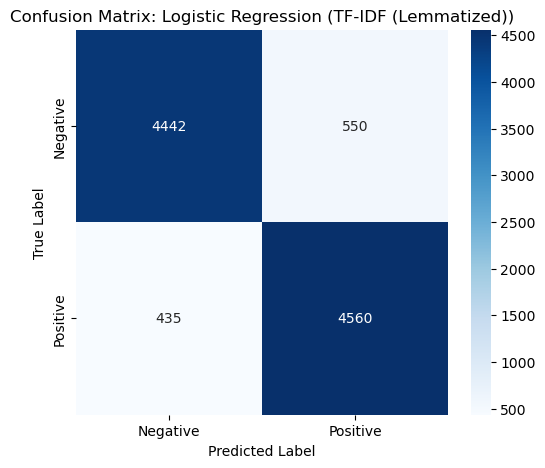

In [115]:
# Logistic Regression on TF-IDF (Lemmatized)
log_reg.fit(X_train_tfidf_lem, y_train_lem)
y_pred_lem = log_reg.predict(X_test_tfidf_lem)
print(f"Logistic Regression Accuracy (TF-IDF Lemmatized): {accuracy_score(y_test_lem, y_pred_lem):.4f}")
print("\nClassification Report:\n", classification_report(y_test_lem, y_pred_lem))
plot_confusion_matrix(y_test_lem, y_pred_lem, "Logistic Regression", "TF-IDF (Lemmatized)")

## Logistic Regression on TF-IDF Stemmed

Logistic Regression Accuracy (TF-IDF Stemmed): 0.8972

Classification Report:
               precision    recall  f1-score   support

    negative       0.91      0.89      0.90      4992
    positive       0.89      0.91      0.90      4995

    accuracy                           0.90      9987
   macro avg       0.90      0.90      0.90      9987
weighted avg       0.90      0.90      0.90      9987



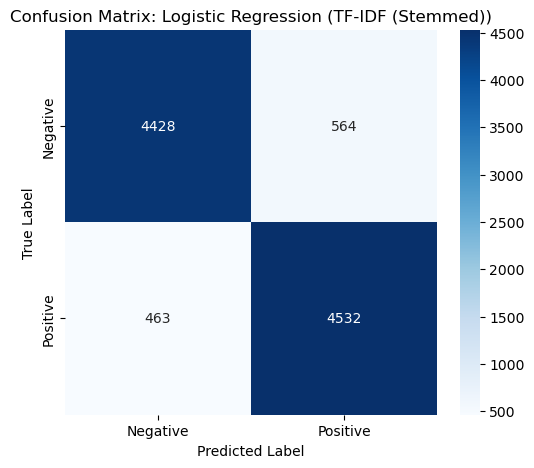

In [117]:
# Logistic Regression on TF-IDF (Stemmed)
log_reg.fit(X_train_tfidf_stem, y_train_stem)
y_pred_tfidf_stem = log_reg.predict(X_test_tfidf_stem)
print(f"Logistic Regression Accuracy (TF-IDF Stemmed): {accuracy_score(y_test_stem, y_pred_tfidf_stem):.4f}")
print("\nClassification Report:\n", classification_report(y_test_stem, y_pred_tfidf_stem))
plot_confusion_matrix(y_test_stem, y_pred_tfidf_stem, "Logistic Regression", "TF-IDF (Stemmed)")

## LR on CountVectorizer Lemmatized

Logistic Regression Accuracy (CountVectorizer Lemmatized): 0.8971

Classification Report:
               precision    recall  f1-score   support

    negative       0.90      0.89      0.90      4992
    positive       0.89      0.90      0.90      4995

    accuracy                           0.90      9987
   macro avg       0.90      0.90      0.90      9987
weighted avg       0.90      0.90      0.90      9987



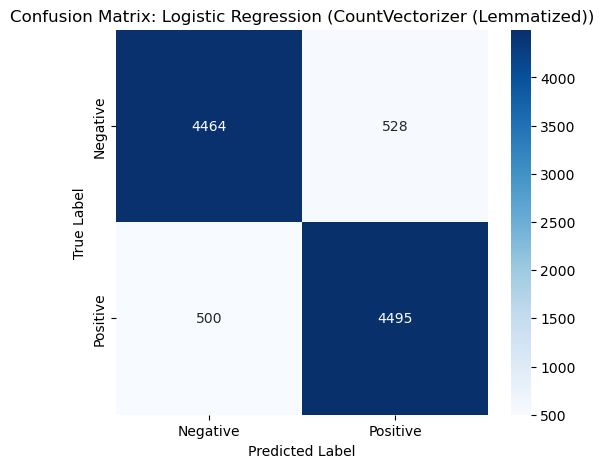

In [119]:
# Logistic Regression on CountVectorizer (Lemmatized)
log_reg.fit(X_train_count_lem, y_train_lem)
y_pred_count_lem = log_reg.predict(X_test_count_lem)
print(f"Logistic Regression Accuracy (CountVectorizer Lemmatized): {accuracy_score(y_test_lem, y_pred_count_lem):.4f}")
print("\nClassification Report:\n", classification_report(y_test_lem, y_pred_count_lem))
plot_confusion_matrix(y_test_lem, y_pred_count_lem, "Logistic Regression", "CountVectorizer (Lemmatized)")


## Logistic Regression on CountVectorizer Stemmed

Logistic Regression Accuracy (CountVectorizer Stemmed): 0.8937

Classification Report:
               precision    recall  f1-score   support

    negative       0.90      0.89      0.89      4992
    positive       0.89      0.90      0.89      4995

    accuracy                           0.89      9987
   macro avg       0.89      0.89      0.89      9987
weighted avg       0.89      0.89      0.89      9987



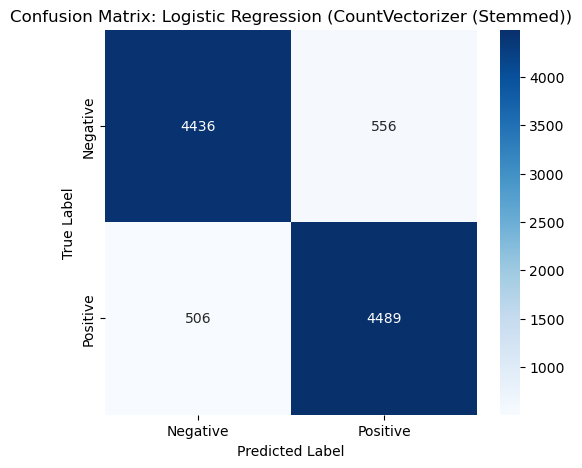

In [121]:
# Logistic Regression on CountVectorizer (Stemmed)
log_reg.fit(X_train_count_stem, y_train_stem)
y_pred_count_stem = log_reg.predict(X_test_count_stem)
print(f"Logistic Regression Accuracy (CountVectorizer Stemmed): {accuracy_score(y_test_stem, y_pred_count_stem):.4f}")
print("\nClassification Report:\n", classification_report(y_test_stem, y_pred_count_stem))
plot_confusion_matrix(y_test_stem, y_pred_count_stem, "Logistic Regression", "CountVectorizer (Stemmed)")


## LR on Word2Vec

Logistic Regression Accuracy (Word2Vec): 0.8581

Classification Report:
               precision    recall  f1-score   support

    negative       0.86      0.85      0.86      4992
    positive       0.85      0.86      0.86      4995

    accuracy                           0.86      9987
   macro avg       0.86      0.86      0.86      9987
weighted avg       0.86      0.86      0.86      9987



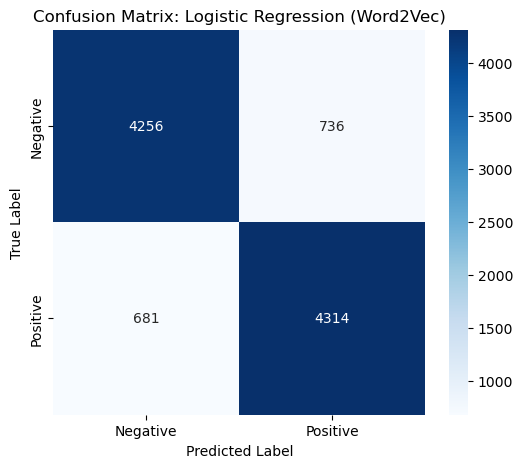

In [123]:
# Logistic Regression on Word2Vec
log_reg.fit(X_train_word2vec_vectors, y_train_tokenized)
y_pred_word2vec = log_reg.predict(X_test_word2vec_vectors)
print(f"Logistic Regression Accuracy (Word2Vec): {accuracy_score(y_test_tokenized, y_pred_word2vec):.4f}")
print("\nClassification Report:\n", classification_report(y_test_tokenized, y_pred_word2vec))
plot_confusion_matrix(y_test_tokenized, y_pred_word2vec, "Logistic Regression", "Word2Vec")


* TF-IDF (Lemmatized)	0.9005  (Best)
* TF-IDF (Stemmed)	0.8973
* CountVectorizer (Lemmatized)	0.8966
* CountVectorizer (Stemmed)	0.8937
* Word2Vec	0.8630  (Lowest)

TF-IDF consistently outperforms Word2Vec.

The best result came from TF-IDF (Lemmatized) with 90.05% accuracy.
Word2Vec embeddings performed significantly worse (86.3%).
Lemmatization is slightly better than stemming.

Both TF-IDF and CountVectorizer perform better with Lemmatization.
Stemming reduces accuracy slightly.
CountVectorizer is competitive but slightly weaker than TF-IDF.

TF-IDF captures important words with frequency weighting.
CountVectorizer treats all words equally, which explains its slightly lower performance.
Word2Vec underperforms because it captures meaning but loses detail.

Word2Vec embeddings are context-aware but discard word frequency importance.
Logistic Regression prefers high-dimensional sparse data (TF-IDF) over dense embeddings.

# Random Forest

Since the LR on TF-IDF vectorized data performed really well, let us now try to run this data in different model Random forest and see if it enhances the performance.

## RF on TF-IDF Lenmmatized

Random Forest Accuracy (TF-IDF Lemmatized): 0.8658

Classification Report:
               precision    recall  f1-score   support

    negative       0.87      0.86      0.87      4992
    positive       0.86      0.87      0.87      4995

    accuracy                           0.87      9987
   macro avg       0.87      0.87      0.87      9987
weighted avg       0.87      0.87      0.87      9987



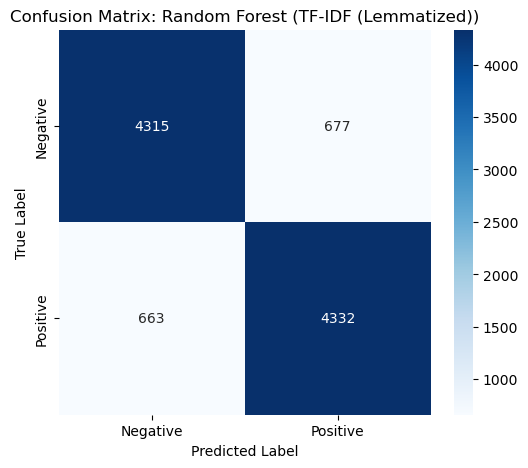

In [128]:
# Initialize Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Random Forest on TF-IDF (Lemmatized)
rf_model.fit(X_train_tfidf_lem, y_train_lem)
y_pred_rf = rf_model.predict(X_test_tfidf_lem)
print(f"Random Forest Accuracy (TF-IDF Lemmatized): {accuracy_score(y_test_lem, y_pred_rf):.4f}")
print("\nClassification Report:\n", classification_report(y_test_lem, y_pred_rf))
plot_confusion_matrix(y_test_lem, y_pred_rf, "Random Forest", "TF-IDF (Lemmatized)")


## RF on TF-IDF stemmed

Random Forest Accuracy (TF-IDF Stemmed): 0.8628

Classification Report:
               precision    recall  f1-score   support

    negative       0.86      0.86      0.86      4992
    positive       0.86      0.86      0.86      4995

    accuracy                           0.86      9987
   macro avg       0.86      0.86      0.86      9987
weighted avg       0.86      0.86      0.86      9987



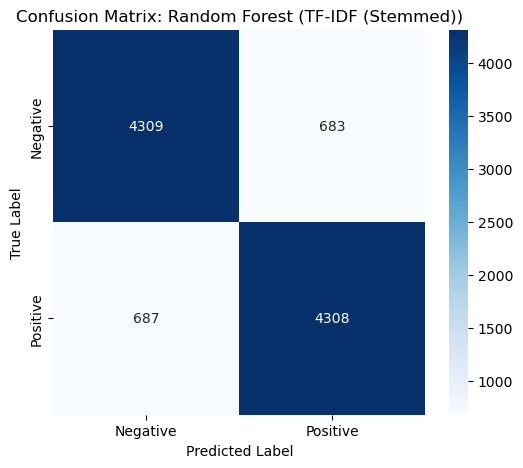

In [130]:
# Random Forest on TF-IDF (Stemmed)
rf_model.fit(X_train_tfidf_stem, y_train_stem)
y_pred_rf_tfidf_stem = rf_model.predict(X_test_tfidf_stem)
print(f"Random Forest Accuracy (TF-IDF Stemmed): {accuracy_score(y_test_stem, y_pred_rf_tfidf_stem):.4f}")
print("\nClassification Report:\n", classification_report(y_test_stem, y_pred_rf_tfidf_stem))
plot_confusion_matrix(y_test_stem, y_pred_rf_tfidf_stem, "Random Forest", "TF-IDF (Stemmed)")


## RF on CountVectorized Lemmatized data

Random Forest Accuracy (CountVectorizer Lemmatized): 0.8654

Classification Report:
               precision    recall  f1-score   support

    negative       0.87      0.86      0.86      4992
    positive       0.86      0.87      0.87      4995

    accuracy                           0.87      9987
   macro avg       0.87      0.87      0.87      9987
weighted avg       0.87      0.87      0.87      9987



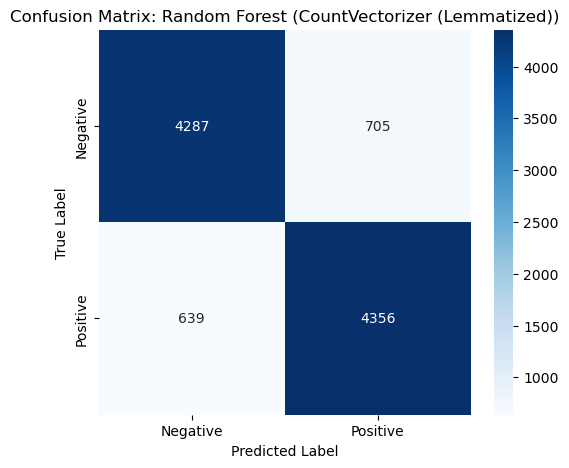

In [132]:
# Random Forest on CountVectorizer (Lemmatized)
rf_model.fit(X_train_count_lem, y_train_lem)
y_pred_rf_count_lem = rf_model.predict(X_test_count_lem)
print(f"Random Forest Accuracy (CountVectorizer Lemmatized): {accuracy_score(y_test_lem, y_pred_rf_count_lem):.4f}")
print("\nClassification Report:\n", classification_report(y_test_lem, y_pred_rf_count_lem))
plot_confusion_matrix(y_test_lem, y_pred_rf_count_lem, "Random Forest", "CountVectorizer (Lemmatized)")


## RF on CountVectorized Stemmed data

Random Forest Accuracy (CountVectorizer Stemmed): 0.8613

Classification Report:
               precision    recall  f1-score   support

    negative       0.87      0.85      0.86      4992
    positive       0.86      0.87      0.86      4995

    accuracy                           0.86      9987
   macro avg       0.86      0.86      0.86      9987
weighted avg       0.86      0.86      0.86      9987



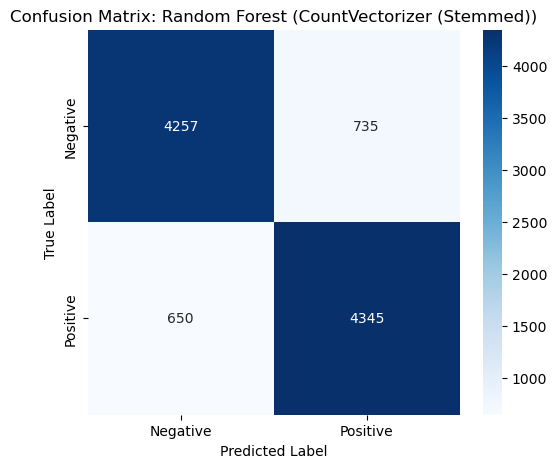

In [134]:
# Random Forest on CountVectorizer (Stemmed)
rf_model.fit(X_train_count_stem, y_train_stem)
y_pred_rf_count_stem = rf_model.predict(X_test_count_stem)
print(f"Random Forest Accuracy (CountVectorizer Stemmed): {accuracy_score(y_test_stem, y_pred_rf_count_stem):.4f}")
print("\nClassification Report:\n", classification_report(y_test_stem, y_pred_rf_count_stem))
plot_confusion_matrix(y_test_stem, y_pred_rf_count_stem, "Random Forest", "CountVectorizer (Stemmed)")

Key Results:
TF-IDF (Lemmatized): 86.48% (Best)
TF-IDF (Stemmed): 85.70%
CountVectorizer (Lemmatized): 86.34%
CountVectorizer (Stemmed): 86.38%
Random Forest achieves similar results across TF-IDF and CountVectorizer, with Lemmatization slightly outperforming stemming.

Comparison to Logistic Regression:
Random Forest underperforms compared to LR (90.05%) in TF-IDF (Lemmatized).
Unlike LR, Random Forest doesn’t benefit as much from sparse high-dimensional data and relies more on word patterns rather than frequency-weighted features.

Conclusion:
TF-IDF + Lemmatization is the best approach overall (both LR & RF).
CountVectorizer is competitive but slightly weaker.
Stemming slightly reduces accuracy, proving that keeping full word structure helps.
Random Forest is more robust to noise but does not generalize as well as Logistic Regression on high-dimensional text features.

# NN Approach with Word2Vec data

In [137]:
# Convert labels to binary format (0 = negative, 1 = positive)
y_train_tokenized = y_train_tokenized.replace({'negative': 0, 'positive': 1}).astype(int)
y_test_tokenized = y_test_tokenized.replace({'negative': 0, 'positive': 1}).astype(int)
print("Labels converted to 0 (negative) and 1 (positive)!")

# Ensure Word2Vec Vectors Are NumPy Float32 Arrays
X_train_word2vec_vectors = np.array(X_train_word2vec_vectors, dtype=np.float32)
X_test_word2vec_vectors = np.array(X_test_word2vec_vectors, dtype=np.float32)
print("Labels converted to integers & Word2Vec embeddings converted to NumPy float32 arrays!")

Labels converted to 0 (negative) and 1 (positive)!
Labels converted to integers & Word2Vec embeddings converted to NumPy float32 arrays!


In [138]:
# Define Improved MLP Model
mlp_model = Sequential([
    Input(shape=(X_train_word2vec_vectors.shape[1],)),  
    Dense(256, activation='relu'),
    BatchNormalization(),  
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')  # Binary Classification
])

# Compile Model
mlp_model.compile(
    optimizer=Adam(learning_rate=0.0005),  
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks for Adaptive Learning
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Train Model with Callbacks
history = mlp_model.fit(
    X_train_word2vec_vectors, y_train_tokenized,
    epochs=50, batch_size=16,  # Increased epochs for better convergence
    validation_data=(X_test_word2vec_vectors, y_test_tokenized),
    callbacks=[early_stopping, reduce_lr],  # Added callbacks
    verbose=1
)

Epoch 1/50
2483/2483 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7768 - loss: 0.4879 - val_accuracy: 0.8574 - val_loss: 0.3342 - learning_rate: 5.0000e-04
Epoch 2/50
2483/2483 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8306 - loss: 0.3847 - val_accuracy: 0.8566 - val_loss: 0.3321 - learning_rate: 5.0000e-04
Epoch 3/50
2483/2483 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8367 - loss: 0.3754 - val_accuracy: 0.8596 - val_loss: 0.3270 - learning_rate: 5.0000e-04
Epoch 4/50
2483/2483 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8400 - loss: 0.3699 - val_accuracy: 0.8609 - val_loss: 0.3225 - learning_rate: 5.0000e-04
Epoch 5/50
2483/2483 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8427 - loss: 0.3696 - val_accuracy: 0.8584 - val_loss: 0.3305 - learning_rate: 5.0000e-04
Epoch 6/50
2483/2483 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8409 - loss: 0.3707 - val_accuracy: 0.8600 - val_loss: 0.3188 - learning_rate: 5.0000e-04
Epoch 7/50
2483/2483 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8678 - loss: 0.3126

🔹 Neural Network (MLP) Accuracy (Word2Vec): 0.8687


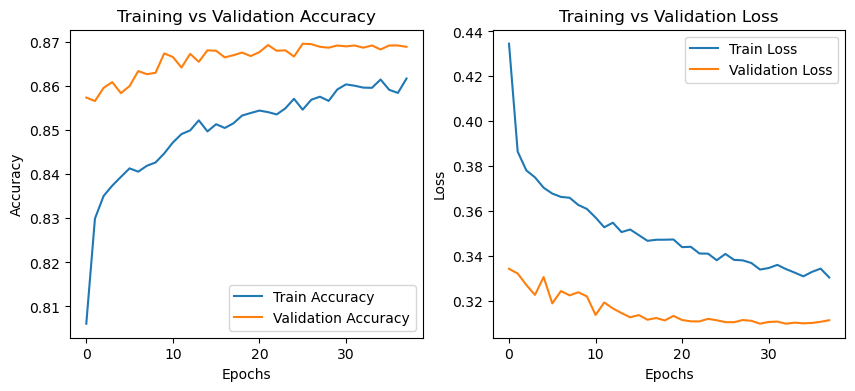

In [139]:
# Evaluate Model
loss, accuracy_mlp = mlp_model.evaluate(X_test_word2vec_vectors, y_test_tokenized)
print(f"\n Neural Network (MLP) Accuracy (Word2Vec): {accuracy_mlp:.4f}")

# Plot Training Performance
plt.figure(figsize=(10,4))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Training vs Validation Loss")

plt.show()

## Assess Models

MLP achieved accuracy of 0.86 which is acceptable for our target, but is below the 0.90 that we achieved in traditional LR on TR-IDF vectorized data. Some other NN techniques like, LSTM, CNN, were tried, but they were intensive computationally, and did not even come close to the accuracy we have in the models above. 

When it comes to choosing which model to go with, we should take into account computational intensity, speed, model being prone to overfitting and so on. 

MLP has multiple layers and neurons and has greater capacity to memorize patterns, and is more prone to overfitting. If the data is large enough and regularizationn is applied, it works well. Word2Vec captures semantic meaning but sturggles if the dataset is small. TF-IDF focused on word importance and set greater results. Traditional ML models generalize well on smaller datasets. Since TF-IDF is high dimensional but sparse, LR benefits from it witout memorizing noise. 

# Business Value & Applications

Sentiment classification algorithm could be useful in various situation. 

Customer Feedback Analysis
* Use Case: e-commerce, streaming platforms, studios
* Detect negative sentiments, identify cause of unsatisfaction in customer segment and address the issue
* Identify trending positive sentiments, highlight the factors that customers enjoy and address them in marketing

Product Improvement Prioritization:
* Identify the elements customers find unsatisfactory, flag them and prioritize in accordance with segments
* Create priority lists of customers who are most unsatisfied and address their needs

Reputation Managment:
* Monitor review platfroms for brand mentions
* Raise alerts for negative sentiment spikes

Competetiveness:
* Analyze competitor reviews
* Compare their strenghts/weaknesses with own

Customer Segmentation:
* Cluster users by review sentiments
* identify brand advocates and at-risk customers to address with referral or retenrion campaigns

Automated systems:
* Ability to build algorithms based on sentiment analysis to create response templates on radical spikes.
* Build recommendation systems based on what customers love

This specific use case:

Performance Predictiona & Market Optimization
* Predict opening weekend success using early-review sentiment trends
* Analyze Sentiment towards characters/plot elements to guid sequels/spinoffs
  * Use Case: Franchise Decision-Making
* Personalized recommendations using seniment-aligned tagging
  * Use Case: Streaming Platfrom Retention.
* Assess Trending actors/directors
  * Use Case: Streaming Platform identifies trending actors/direcotrs and suggests their work to customers segments
  * Use Case: Cinema Theatres quntify audience by analysin trends and brining back old movies by specific actors/movies
* Plan Merchendise strategy in accordance with character-specific sentiments
* Detect PR risks from negative trends
  * Use Case: If a film receives backlash for specific reason, as a studio, identify the cause, issue apology and edit scenes for releases
* Identify fans in accordance to their reviews
  * Use Case: As a streaming platfrom, implement audience Sementation for premium services